# Notebook 01 — Exploratory Data Analysis & Descriptive Statistics

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub — Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-03

---

### Purpose

This notebook provides a comprehensive **descriptive analysis** of every variable considered for the tourism demand model. It generates the tables and figures for **Chapter 4** of the thesis (Descriptive Analysis).

The analysis is organised into five thematic blocks:

1. **Target variable** — Foreign overnight stays in Poland: level, trend, seasonality, distribution, and the COVID-19 structural break.
2. **Economic / price variables** — HICP indices, exchange rates, and real GDP of origin markets: evolution, cross-country comparison, and preliminary price-competitiveness insights.
3. **Transport / aviation** — Airline seat capacity and air passenger flows: connectivity growth, airport composition, and the low-cost carrier narrative.
4. **Sentiment & demographic** — Consumer confidence and population of origin countries.
5. **Synthesis** — Summary of findings and variables carried forward to modelling.

**Scope boundaries:** This notebook is strictly descriptive. No formal statistical tests (Notebook 03), no feature engineering (Notebook 04), and no modelling (Notebooks 05–08).

**Prerequisite:** Notebook 00 (Data Loading & Inspection) must have been run first. The filter values used throughout this notebook were verified there.

---

## 0. Environment & Configuration

In [185]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# --- PLOT SETTINGS ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),     
    'figure.dpi': 120,              
    'font.family': 'DejaVu Sans',   
    'axes.titlesize': 13,           
    'axes.titleweight': 'bold',     
    'axes.labelsize': 11,           
    'font.size': 10,                
    'legend.fontsize': 9,           
    'axes.spines.top': False,       
    'axes.spines.right': False,     
    'axes.grid': True,
    'grid.alpha': 0.4,              
    'grid.linestyle': '--',         
    'lines.linewidth': 2.0,         
    'lines.markersize': 6,
    'savefig.bbox': 'tight',        
    'savefig.dpi': 200,             
    'savefig.facecolor': 'white',
})

# Consistent colour palette across all notebooks
COLORS = {
    'primary':   '#2c3e50',
    'secondary': '#e74c3c',
    'accent1':   '#3498db',
    'accent2':   '#2ecc71',
    'accent3':   '#f39c12',
    'accent4':   '#9b59b6',
    'gray':      '#95a5a6',
    'covid':     '#e74c3c',
}

# COVID-19 period boundaries (used in every time-series plot)
COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-30')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Environment ready.')

Environment ready.


In [186]:
# --- PROJECT PATHS ---
DATA_RAW = os.path.join('..', 'data', 'raw')
FIGURES  = os.path.join('..', 'figures', 'eda')
os.makedirs(FIGURES, exist_ok=True)

# --- FILE CATALOGUE ---
# Mirrors the catalogue from Notebook 00.
FILES = {
    # Target
    'nights':       os.path.join(DATA_RAW, 'tourism',
                        'tour_occ_nights_accommodation_PL_2003-.csv'),
    # Economic
    'hicp_m':       os.path.join(DATA_RAW, 'economic',
                        'prc_hicp_midx__relevant-countries-2011-.csv'),
    'hicp_a':       os.path.join(DATA_RAW, 'economic',
                        'prc_hicp_aind__specific-inflation.csv'),
    'exr':          os.path.join(DATA_RAW, 'economic',
                        'ert_bil_eur_m__exchange-rates-eur-pln-usd-2003-.csv'),
    'gdp_real':     os.path.join(DATA_RAW, 'economic',
                        'namq_10_gdp__real-gdp-CLV-2010.csv'),
    'ppp':          os.path.join(DATA_RAW, 'economic',
                        'prc_ppp_ind__price-level-indices.csv'),
    # Sentiment / Demographic
    'cci':          os.path.join(DATA_RAW, 'demographic',
                        'ei_bsco_m__consumer-conf-indicator.csv'),
    'population':   os.path.join(DATA_RAW, 'demographic',
                        'demo_pjan__population-eur-990-25.csv'),
    # Transport
    'avia_seats':   os.path.join(DATA_RAW, 'transport',
                        'avia_tf_aca__seats-flights-pass-PL-2010-.csv'),
    'avia_pax':     os.path.join(DATA_RAW, 'transport',
                        'avia_paoc__passengers-countries.csv'),
    'avia_airports': os.path.join(DATA_RAW, 'transport',
                        'avia_tf_apal_passengers_airports_PL-2003-.csv'),
    # Tourism (supplementary)
    'tour_cap':     os.path.join(DATA_RAW, 'tourism',
                        'tour_cap_nat__tourism-infraestructure.csv'),
}

# Verify files exist
print('File verification:')
for name, path in FILES.items():
    tag = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{tag}] {name}: {os.path.basename(path)}')

File verification:
  [OK] nights: tour_occ_nights_accommodation_PL_2003-.csv
  [OK] hicp_m: prc_hicp_midx__relevant-countries-2011-.csv
  [OK] hicp_a: prc_hicp_aind__specific-inflation.csv
  [OK] exr: ert_bil_eur_m__exchange-rates-eur-pln-usd-2003-.csv
  [OK] gdp_real: namq_10_gdp__real-gdp-CLV-2010.csv
  [OK] ppp: prc_ppp_ind__price-level-indices.csv
  [OK] cci: ei_bsco_m__consumer-conf-indicator.csv
  [OK] population: demo_pjan__population-eur-990-25.csv
  [OK] avia_seats: avia_tf_aca__seats-flights-pass-PL-2010-.csv
  [OK] avia_pax: avia_paoc__passengers-countries.csv
  [OK] avia_airports: avia_tf_apal_passengers_airports_PL-2003-.csv
  [OK] tour_cap: tour_cap_nat__tourism-infraestructure.csv


### 0.1 Helper Functions

Reusable utilities for loading Eurostat CSVs, printing summaries, and creating consistently styled time-series plots with COVID-19 shading.

In [187]:
# --- COUNTRY NAME ↔ ISO-2 CODE MAPPING ---
# Eurostat datasets use full country names; we need both forms.
NAME_TO_CODE = {
    'Austria': 'AT', 'Croatia': 'HR', 'Czechia': 'CZ',
    'France': 'FR', 'Germany': 'DE', 'Greece': 'EL',
    'Hungary': 'HU', 'Italy': 'IT', 'Netherlands': 'NL',
    'Poland': 'PL', 'Spain': 'ES', 'Sweden': 'SE',
    'United Kingdom': 'UK', 'United States': 'US',
}
CODE_TO_NAME = {v: k for k, v in NAME_TO_CODE.items()}

# Currency full names used in the Eurostat exchange-rate dataset
CURRENCY_NAMES = {
    'PLN': 'Polish zloty',
    'GBP': 'Pound sterling',
    'SEK': 'Swedish krona',
    'CZK': 'Czech koruna',
    'HUF': 'Hungarian forint',
    'USD': 'US dollar',
}


def load_eurostat(path, parse_dates=True):
    """
    Load an Eurostat CSV and optionally parse TIME_PERIOD to datetime.
    Handles monthly (YYYY-MM), quarterly (YYYY-QN), and annual (YYYY) formats.
    """
    df = pd.read_csv(path)
    if parse_dates and 'TIME_PERIOD' in df.columns:
        tp = df['TIME_PERIOD'].astype(str)
        if tp.str.match(r'^\d{4}-\d{2}$').all():           # Monthly
            df['date'] = pd.to_datetime(tp, format='%Y-%m')
        elif tp.str.match(r'^\d{4}-Q\d$').all():            # Quarterly
            df['date'] = pd.PeriodIndex(tp, freq='Q').to_timestamp()
        elif tp.str.match(r'^\d{4}$').all():                # Annual
            df['date'] = pd.to_datetime(tp, format='%Y')
        else:
            df['date'] = pd.to_datetime(tp, errors='coerce')
    return df


def add_geo_code(df):
    """Add an 'iso' column with 2-letter codes mapped from full country names."""
    if 'geo' in df.columns:
        df['iso'] = df['geo'].map(NAME_TO_CODE)
    return df


def covid_shade(ax):
    """Add a semi-transparent COVID-19 period shading to an axes."""
    ax.axvspan(COVID_START, COVID_END, alpha=0.10, color=COLORS['covid'],
               label='COVID-19 period')


def format_year_axis(ax, interval=2):
    """Set x-axis to show years at the given interval."""
    ax.xaxis.set_major_locator(mdates.YearLocator(interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def savefig(name):
    """Save the current figure to the figures/eda/ directory."""
    plt.savefig(os.path.join(FIGURES, name), dpi=150, bbox_inches='tight')


print('Helper functions defined.')

Helper functions defined.


---

## 1. Target Variable — Foreign Overnight Stays in Poland

The dependent variable of this thesis is the monthly number of **overnight stays by foreign tourists** in all types of accommodation establishments in Poland, sourced from Eurostat table `tour_occ_nim`.

As established in Notebook 00, the column `c_resid` provides only an aggregate foreign/domestic/total split — it does **not** break down by individual origin country. The origin-market dimension is captured through the exogenous variables (GDP, HICP, consumer confidence, exchange rates) and validated descriptively using air passenger flows by country pair (`avia_paoc`, Section 3).

**Filters applied** (from the Notebook 00 reference table):  
- `geo = 'Poland'`  
- `c_resid = 'Foreign country'`  
- `unit = 'Number'` (absolute count of overnight stays)  
- `nace_r2 = 'Hotels; holiday and other short-stay accommodation; camping grounds, recreational vehicle parks and trailer parks'` (all accommodation types)

### 1.1 Loading and Filtering the Target Series

In [188]:
# --- LOAD RAW DATA ---
df_nights_raw = load_eurostat(FILES['nights'])

# --- APPLY FILTERS (values verified in Notebook 00) ---
ACCOM_TOTAL = ('Hotels; holiday and other short-stay accommodation; '
               'camping grounds, recreational vehicle parks and trailer parks')

mask = (
    (df_nights_raw['geo'] == 'Poland') &
    (df_nights_raw['c_resid'] == 'Foreign country') &
    (df_nights_raw['unit'] == 'Number') &
    (df_nights_raw['nace_r2'] == ACCOM_TOTAL)
)

df_target = df_nights_raw.loc[mask].copy()

# Build a clean time series indexed by date
ts_foreign = (
    df_target
    .set_index('date')['OBS_VALUE']
    .sort_index()
    .rename('nights')
)

# Restrict to study period (2011 onwards — reliable data)
ts_foreign = ts_foreign[ts_foreign.index >= '2011-01-01']

print(f'Target series: {len(ts_foreign)} monthly observations')
print(f'Period: {ts_foreign.index.min():%Y-%m} → {ts_foreign.index.max():%Y-%m}')
print(f'Range: {ts_foreign.min():,.0f} — {ts_foreign.max():,.0f} nights')
print(f'Missing: {ts_foreign.isna().sum()}')
print()
print(ts_foreign.describe())

Target series: 179 monthly observations
Period: 2011-01 → 2025-11
Range: 83,695 — 2,453,961 nights
Missing: 0

count       179.00
mean    1189104.26
std      485932.70
min       83695.00
25%      867408.50
50%     1204789.00
75%     1505862.50
max     2453961.00
Name: nights, dtype: float64


### 1.2 Time-Series Overview

The figure below presents three complementary views of the target series: the raw monthly level (Panel A), the year-over-year growth rate (Panel B), and a 12-month rolling sum that smooths out seasonality to reveal the underlying trend (Panel C). The red-shaded region marks the COVID-19 pandemic period (March 2020 – June 2021).

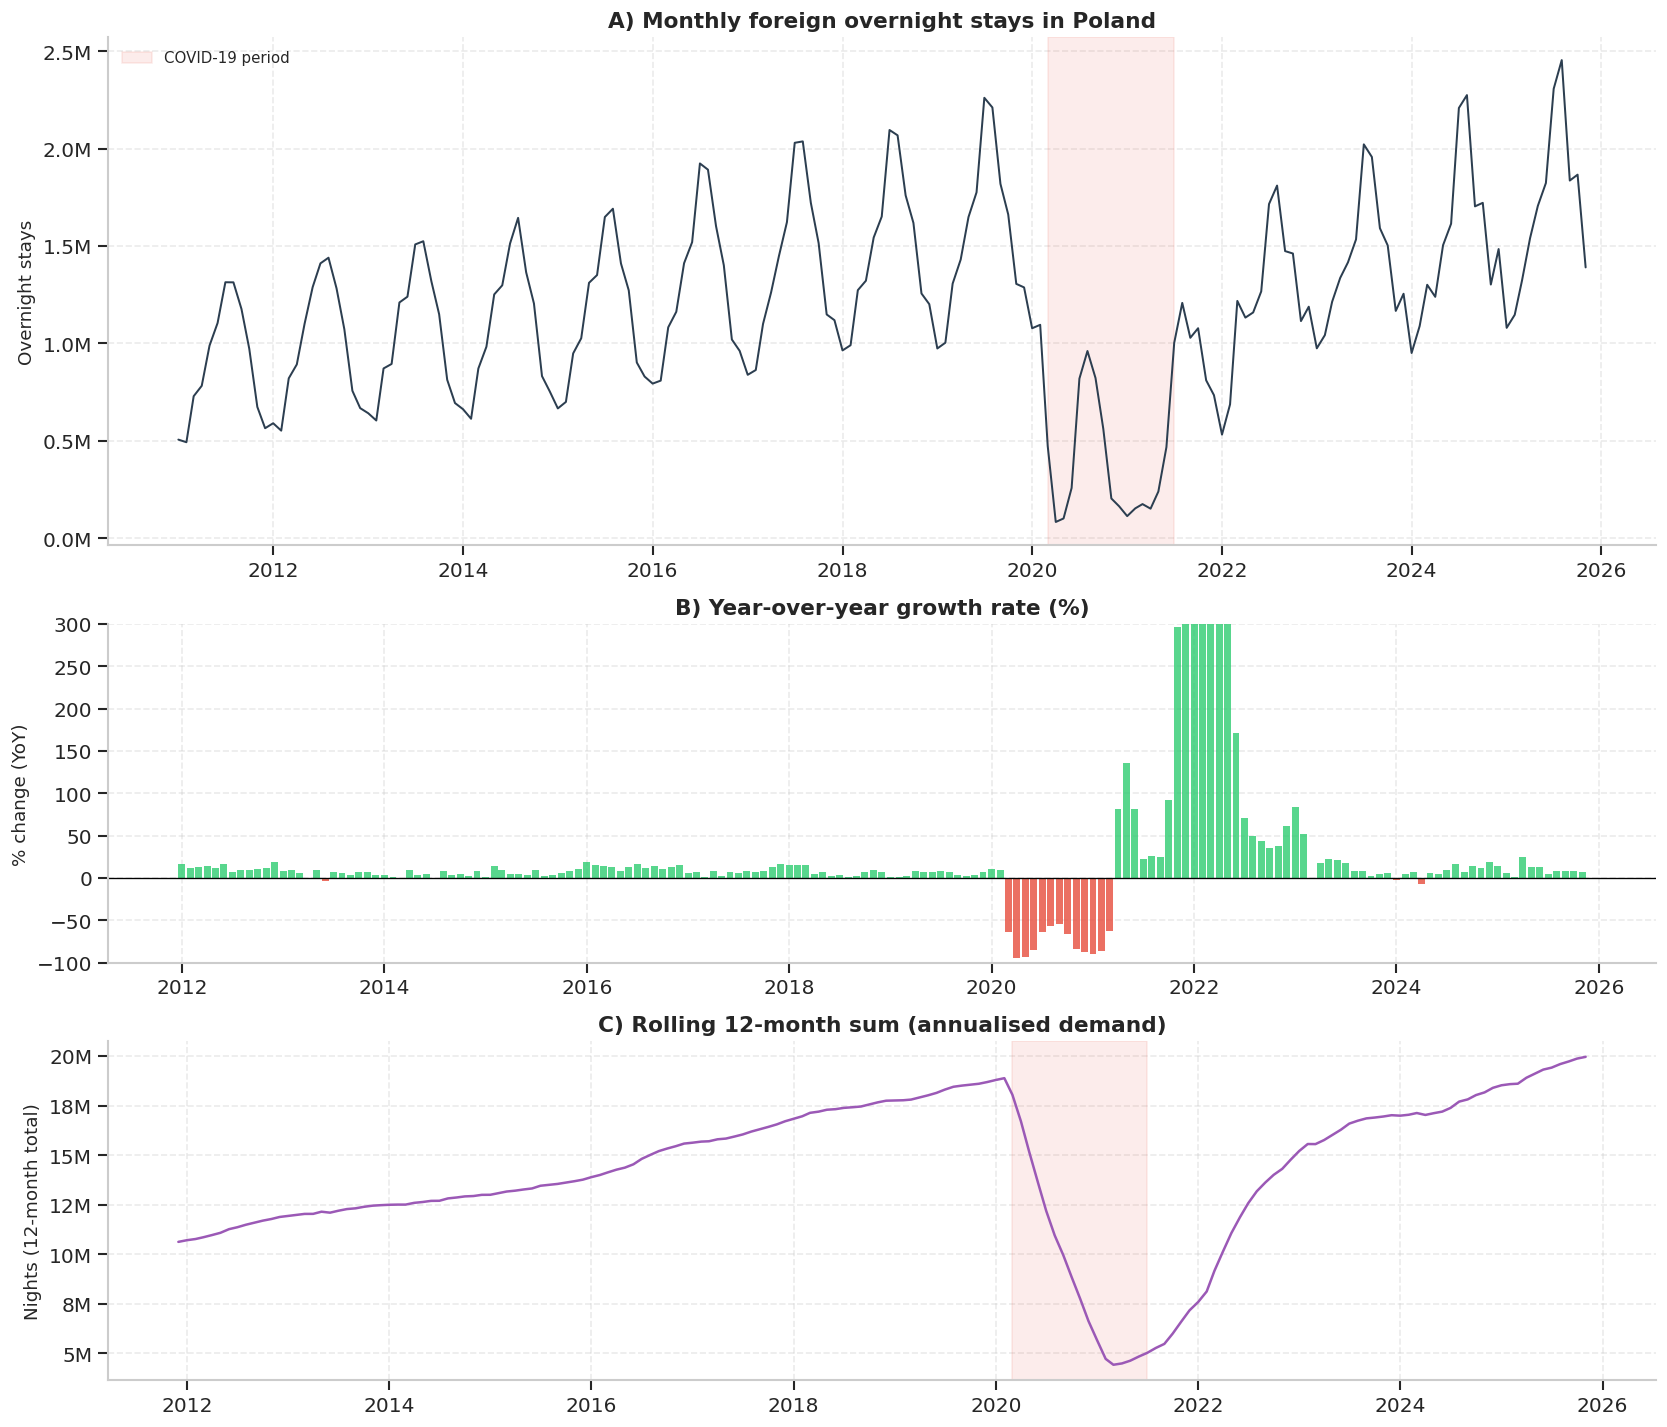

Pre-COVID peak: 2,260,446 nights (2019-07)
COVID trough:   83,695 nights (2020-04)
Latest value:   1,390,200 nights (2025-11)


In [189]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                          gridspec_kw={'height_ratios': [3, 2, 2]})

# --- Panel A: Raw monthly series ---
ax = axes[0]
ax.plot(ts_foreign.index, ts_foreign.values,
        color=COLORS['primary'], linewidth=1.2)
covid_shade(ax)
ax.set_title('A) Monthly foreign overnight stays in Poland')
ax.set_ylabel('Overnight stays')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='upper left')

# --- Panel B: Year-over-year growth ---
yoy = ts_foreign.pct_change(12) * 100
ax = axes[1]
bar_colors = [COLORS['accent2'] if v >= 0 else COLORS['secondary']
              for v in yoy.values]
ax.bar(yoy.index, yoy.values, color=bar_colors, width=25, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('B) Year-over-year growth rate (%)')
ax.set_ylabel('% change (YoY)')
ax.set_ylim(max(-100, np.nanmin(yoy) * 1.1),
            min(300, np.nanmax(yoy) * 1.1))

# --- Panel C: Rolling 12-month sum ---
rolling_12 = ts_foreign.rolling(12).sum()
ax = axes[2]
ax.plot(rolling_12.index, rolling_12.values,
        color=COLORS['accent4'], linewidth=1.5)
covid_shade(ax)
ax.set_title('C) Rolling 12-month sum (annualised demand)')
ax.set_ylabel('Nights (12-month total)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M'))

for ax in axes:
    format_year_axis(ax)

plt.tight_layout()
savefig('01_target_overview.png')
plt.show()

# Key statistics
pre_covid = ts_foreign[ts_foreign.index < '2020-01-01']
covid_period = ts_foreign[
    (ts_foreign.index >= '2020-03-01') & (ts_foreign.index <= '2021-06-01')]
print(f'Pre-COVID peak: {pre_covid.max():,.0f} nights '
      f'({pre_covid.idxmax():%Y-%m})')
print(f'COVID trough:   {covid_period.min():,.0f} nights '
      f'({covid_period.idxmin():%Y-%m})')
print(f'Latest value:   {ts_foreign.iloc[-1]:,.0f} nights '
      f'({ts_foreign.index[-1]:%Y-%m})')

### 1.3 Seasonality Analysis

Tourism demand in Poland exhibits strong seasonality driven by summer holiday patterns. The analysis below quantifies this seasonal pattern through monthly box-plots (with and without the COVID anomaly) and a year-by-month heatmap.

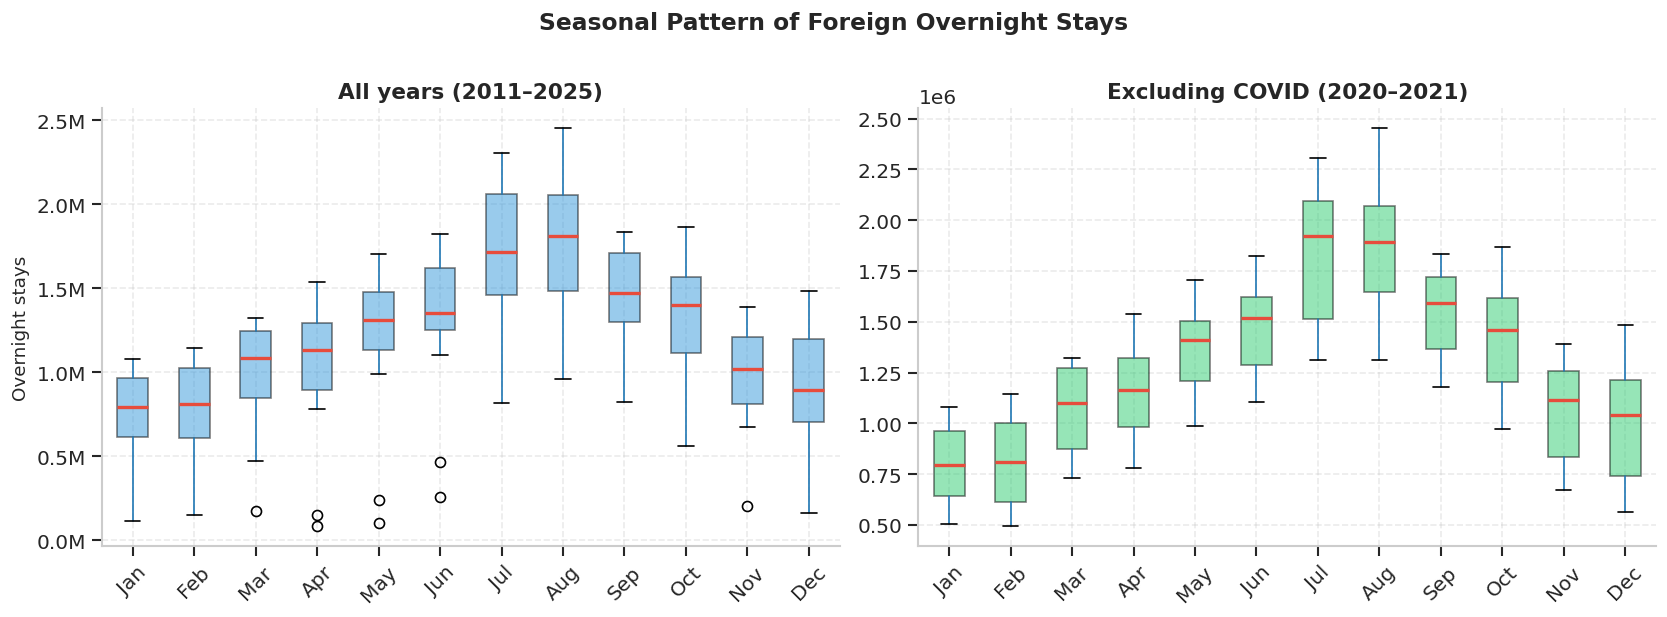

Peak month:   Aug (avg 1,870,409 nights)
Trough month: Jan (avg 782,764 nights)
Peak-to-trough ratio: 2.4x


In [190]:
# Build a seasonal DataFrame
df_season = pd.DataFrame({
    'nights': ts_foreign.values,
    'month':  ts_foreign.index.month,
    'year':   ts_foreign.index.year,
})

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: all years ---
df_season.boxplot(column='nights', by='month', ax=axes[0],
                  patch_artist=True, return_type='dict',
                  boxprops=dict(facecolor=COLORS['accent1'], alpha=0.5),
                  medianprops=dict(color=COLORS['secondary'], linewidth=2))
axes[0].set_xticklabels(MONTH_LABELS, rotation=45)
axes[0].set_title('All years (2011–2025)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Overnight stays')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))

# --- Right: excluding COVID (2020–2021) ---
df_no_covid = df_season[(df_season['year'] < 2020) |
                        (df_season['year'] > 2021)]
df_no_covid.boxplot(column='nights', by='month', ax=axes[1],
                    patch_artist=True, return_type='dict',
                    boxprops=dict(facecolor=COLORS['accent2'], alpha=0.5),
                    medianprops=dict(color=COLORS['secondary'], linewidth=2))
axes[1].set_xticklabels(MONTH_LABELS, rotation=45)
axes[1].set_title('Excluding COVID (2020–2021)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.suptitle('Seasonal Pattern of Foreign Overnight Stays',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('02_seasonality_boxplot.png')
plt.show()

# Peak/trough statistics (excluding COVID)
monthly_avg = df_no_covid.groupby('month')['nights'].mean()
print(f'Peak month:   {MONTH_LABELS[monthly_avg.idxmax()-1]} '
      f'(avg {monthly_avg.max():,.0f} nights)')
print(f'Trough month: {MONTH_LABELS[monthly_avg.idxmin()-1]} '
      f'(avg {monthly_avg.min():,.0f} nights)')
print(f'Peak-to-trough ratio: {monthly_avg.max()/monthly_avg.min():.1f}x')

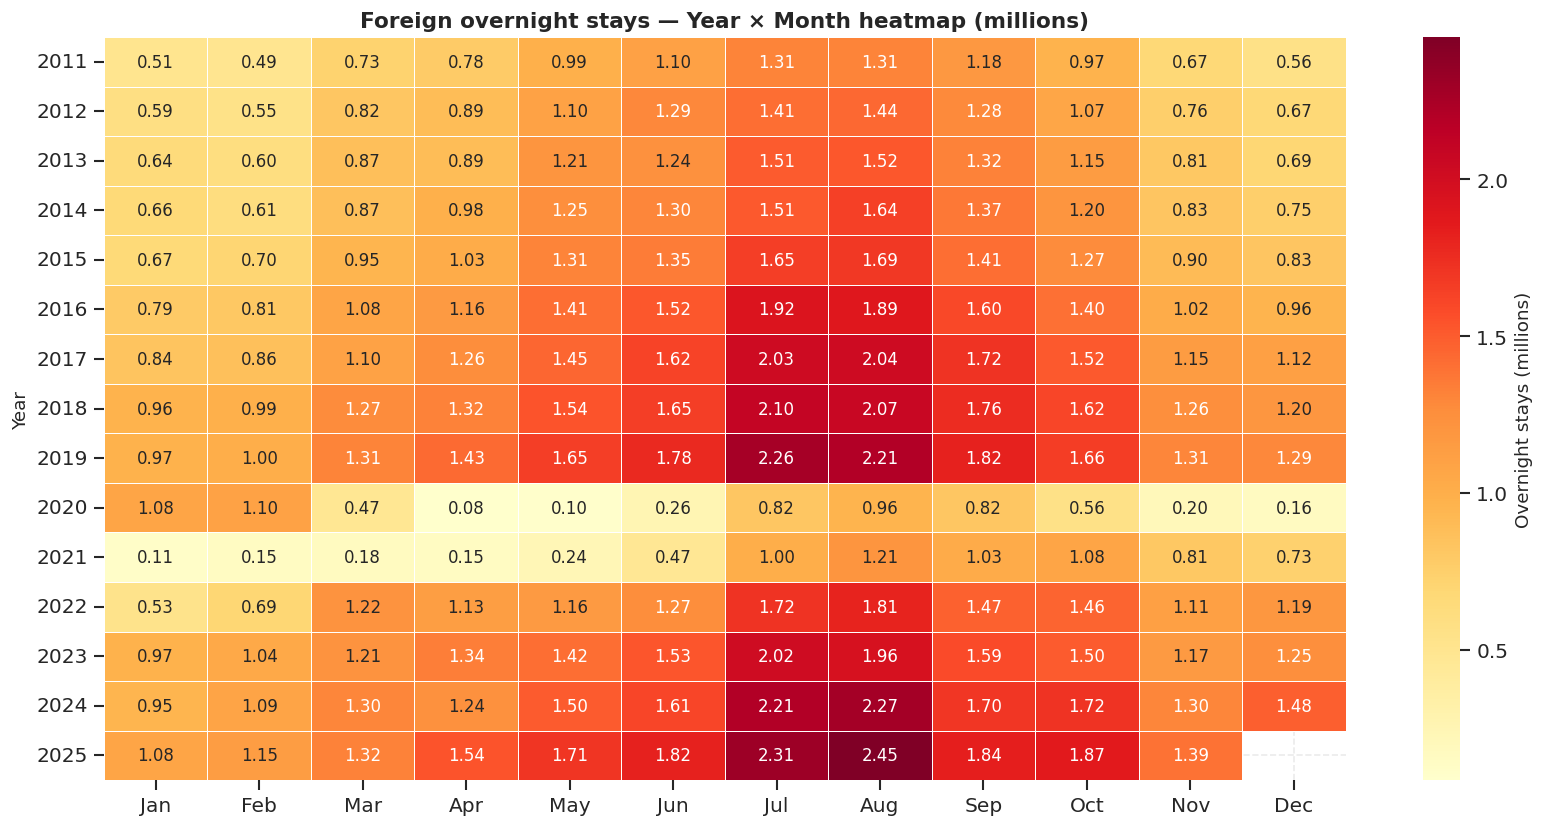

In [191]:
# --- SEASONAL HEATMAP: Year × Month ---
pivot_ym = df_season.pivot_table(index='year', columns='month',
                                  values='nights')
pivot_ym.columns = MONTH_LABELS

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_ym / 1e6, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Overnight stays (millions)'})
ax.set_title('Foreign overnight stays — Year × Month heatmap (millions)',
             fontweight='bold')
ax.set_ylabel('Year')
ax.set_xlabel('')
plt.tight_layout()
savefig('03_heatmap_year_month.png')
plt.show()

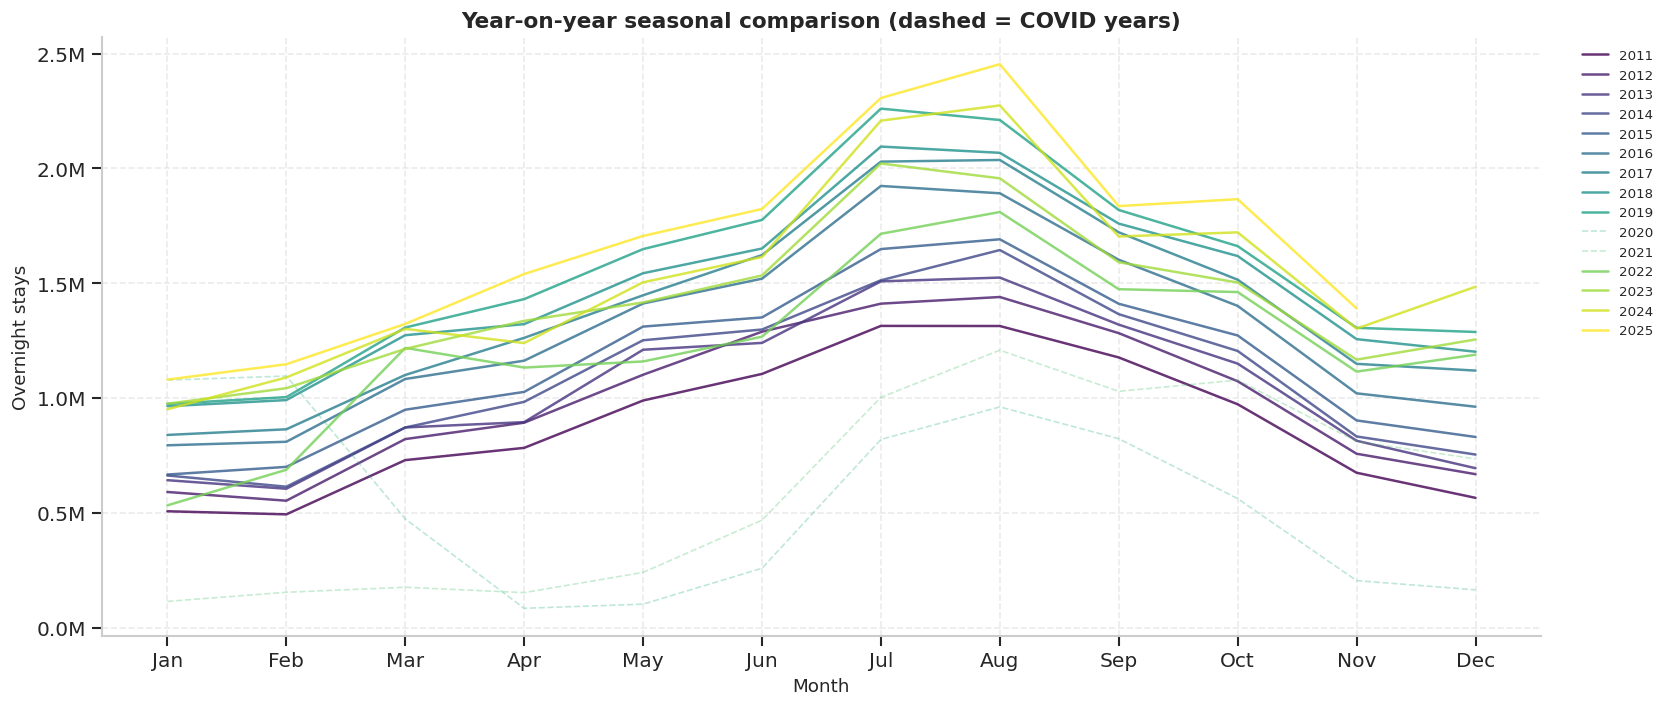

In [192]:
# --- SPAGHETTI PLOT: Year-on-year seasonal comparison ---
fig, ax = plt.subplots(figsize=(14, 6))
years = sorted(df_season['year'].unique())
cmap = plt.cm.viridis(np.linspace(0, 1, len(years)))

for i, (year, grp) in enumerate(df_season.groupby('year')):
    is_covid = 2020 <= year <= 2021
    ax.plot(grp['month'].values, grp['nights'].values,
            color=cmap[i],
            alpha=0.3 if is_covid else 0.8,
            linewidth=1.0 if is_covid else 1.5,
            linestyle='--' if is_covid else '-',
            label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_title('Year-on-year seasonal comparison (dashed = COVID years)',
             fontweight='bold')
ax.set_ylabel('Overnight stays')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
savefig('04_spaghetti_yearly.png')
plt.show()

### 1.4 Distribution & Outliers

Understanding the distribution of the target variable informs modelling decisions. A heavily skewed distribution may benefit from a log transformation; non-normality affects the validity of certain statistical tests.

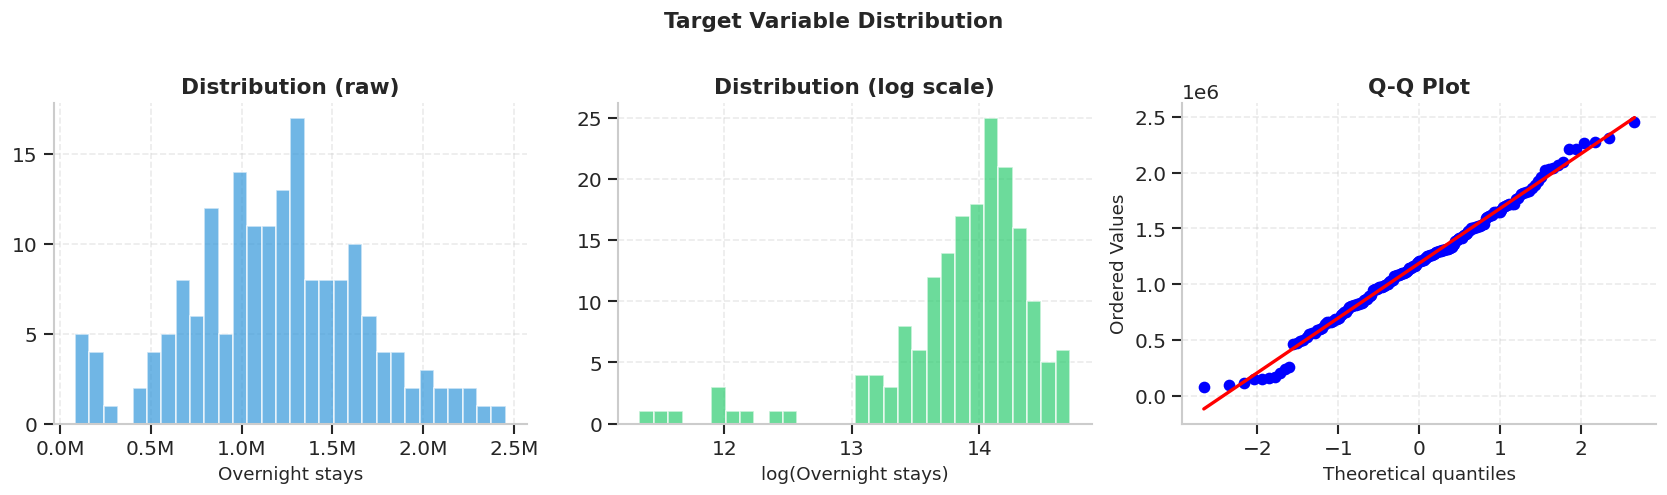

Skewness: 0.011
Kurtosis: -0.036
Shapiro-Wilk test: W=0.9920, p=0.4289


In [193]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram (raw)
axes[0].hist(ts_foreign.values, bins=30,
             color=COLORS['accent1'], alpha=0.7, edgecolor='white')
axes[0].set_title('Distribution (raw)')
axes[0].set_xlabel('Overnight stays')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))

# Histogram (log-transformed)
axes[1].hist(np.log1p(ts_foreign.values), bins=30,
             color=COLORS['accent2'], alpha=0.7, edgecolor='white')
axes[1].set_title('Distribution (log scale)')
axes[1].set_xlabel('log(Overnight stays)')

# Q-Q plot
stats.probplot(ts_foreign.values, plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.suptitle('Target Variable Distribution',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('05_target_distribution.png')
plt.show()

print(f'Skewness: {ts_foreign.skew():.3f}')
print(f'Kurtosis: {ts_foreign.kurtosis():.3f}')
sw_stat, sw_p = stats.shapiro(ts_foreign.values[:min(len(ts_foreign), 500)])
print(f'Shapiro-Wilk test: W={sw_stat:.4f}, p={sw_p:.4f}')

### 1.5 Domestic vs. Foreign Overnight Stays

Although our model focuses on foreign tourists, comparing domestic and foreign demand reveals important structural patterns: the foreign share, differential COVID recovery rates, and seasonal timing differences.

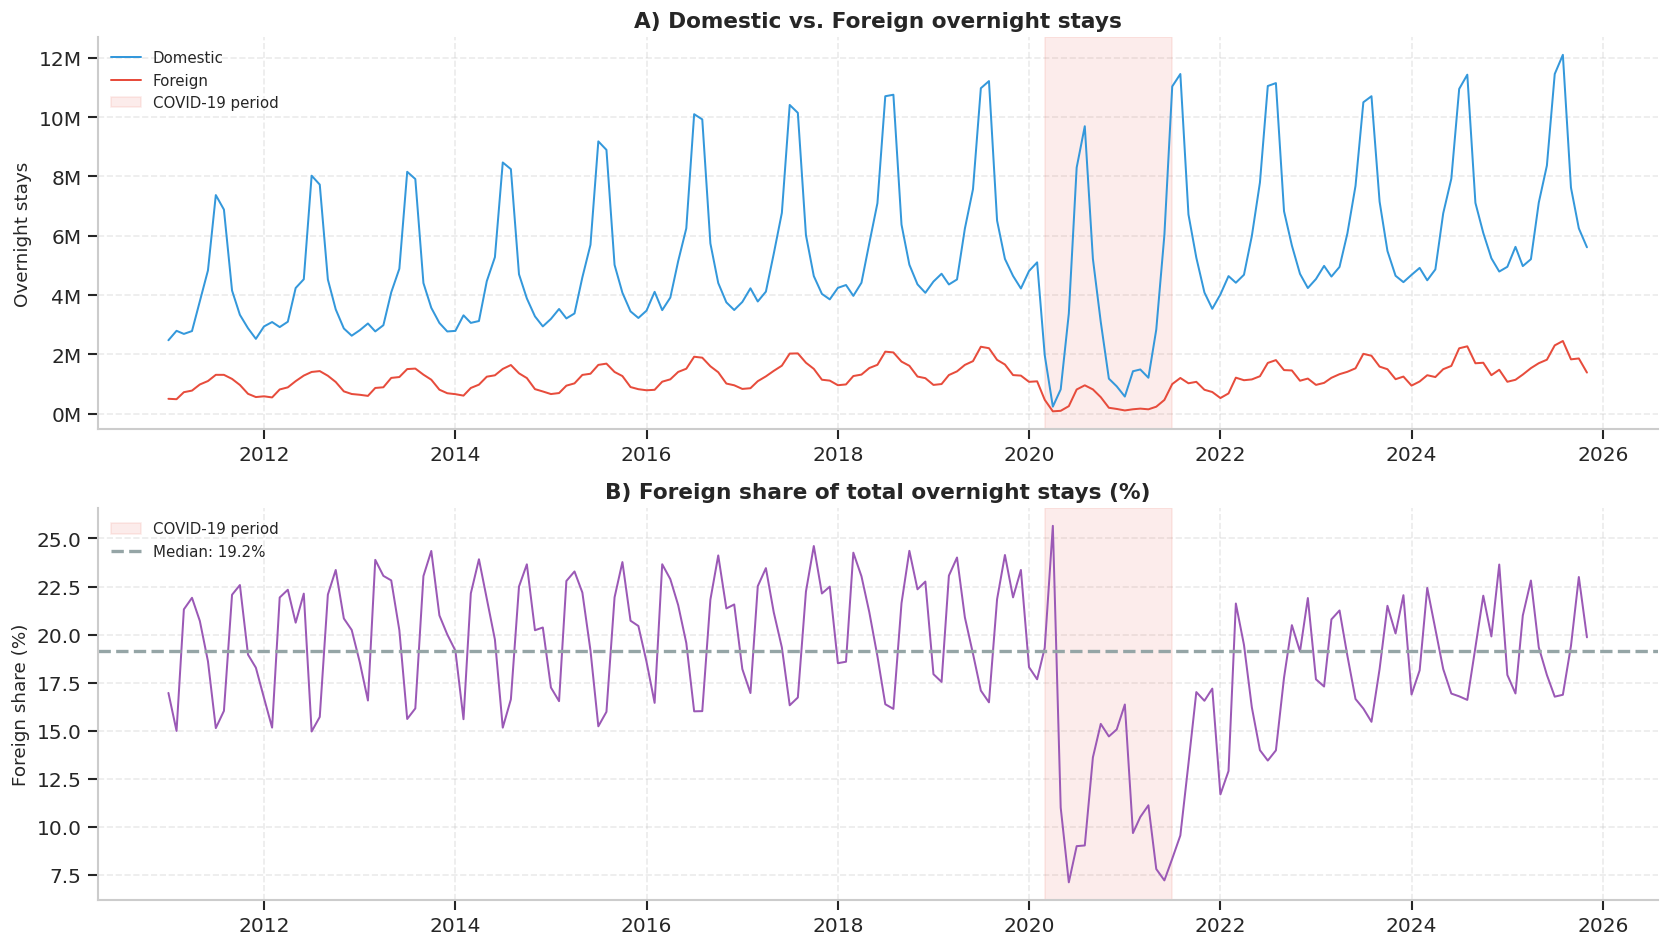

Average foreign share: 18.8%
Foreign share range:   7.1% — 25.7%


In [194]:
# Extract domestic and total series for comparison
def get_nights_series(c_resid_val):
    mask = (
        (df_nights_raw['geo'] == 'Poland') &
        (df_nights_raw['c_resid'] == c_resid_val) &
        (df_nights_raw['unit'] == 'Number') &
        (df_nights_raw['nace_r2'] == ACCOM_TOTAL)
    )
    return (df_nights_raw.loc[mask]
            .set_index('date')['OBS_VALUE']
            .sort_index()
            .loc['2011-01-01':])

ts_domestic = get_nights_series('Domestic country')
ts_total    = get_nights_series('Total')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel A: Levels
ax = axes[0]
ax.plot(ts_domestic.index, ts_domestic.values,
        label='Domestic', color=COLORS['accent1'], linewidth=1.2)
ax.plot(ts_foreign.index, ts_foreign.values,
        label='Foreign', color=COLORS['secondary'], linewidth=1.2)
covid_shade(ax)
ax.set_title('A) Domestic vs. Foreign overnight stays')
ax.set_ylabel('Overnight stays')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()

# Panel B: Foreign share
foreign_share = (ts_foreign / ts_total * 100).dropna()
ax = axes[1]
ax.plot(foreign_share.index, foreign_share.values,
        color=COLORS['accent4'], linewidth=1.2)
covid_shade(ax)
ax.set_title('B) Foreign share of total overnight stays (%)')
ax.set_ylabel('Foreign share (%)')
ax.axhline(foreign_share.median(), ls='--', color=COLORS['gray'],
           label=f'Median: {foreign_share.median():.1f}%')
ax.legend()

for ax in axes:
    format_year_axis(ax)

plt.tight_layout()
savefig('06_domestic_vs_foreign.png')
plt.show()

print(f'Average foreign share: {foreign_share.mean():.1f}%')
print(f'Foreign share range:   {foreign_share.min():.1f}% — {foreign_share.max():.1f}%')

---

## 2. Economic / Price Variables

This section examines the economic variables that will form the core of the demand model: the Harmonised Index of Consumer Prices (HICP), bilateral exchange rates, and real GDP of origin markets. Together, these variables capture the **price competitiveness** of Poland as a tourism destination and the **income effect** in origin countries.

### 2.1 HICP — Harmonised Index of Consumer Prices

The HICP is the numerator and denominator of the **relative tourism price** formula (Song et al., 2010). A faster-rising Polish HICP relative to origin countries means Poland is becoming more expensive for foreign tourists, which is expected to reduce demand.

The dataset is pre-filtered to `coicop = 'All-items HICP'` and `unit = 'Index, 2015=100'`.

In [195]:
# --- LOAD HICP MONTHLY ---
df_hicp = load_eurostat(FILES['hicp_m'])
df_hicp = add_geo_code(df_hicp)

# All values are already 'All-items HICP', index 2015=100
print(f'Shape: {df_hicp.shape}')
print(f'Countries: {sorted(df_hicp["iso"].dropna().unique())}')
print(f'Period: {df_hicp["TIME_PERIOD"].min()} → {df_hicp["TIME_PERIOD"].max()}')

Shape: (4067, 12)
Countries: ['AT', 'CZ', 'DE', 'EL', 'ES', 'FR', 'HR', 'HU', 'IT', 'NL', 'PL', 'SE', 'UK', 'US']
Period: 2003-01 → 2025-12


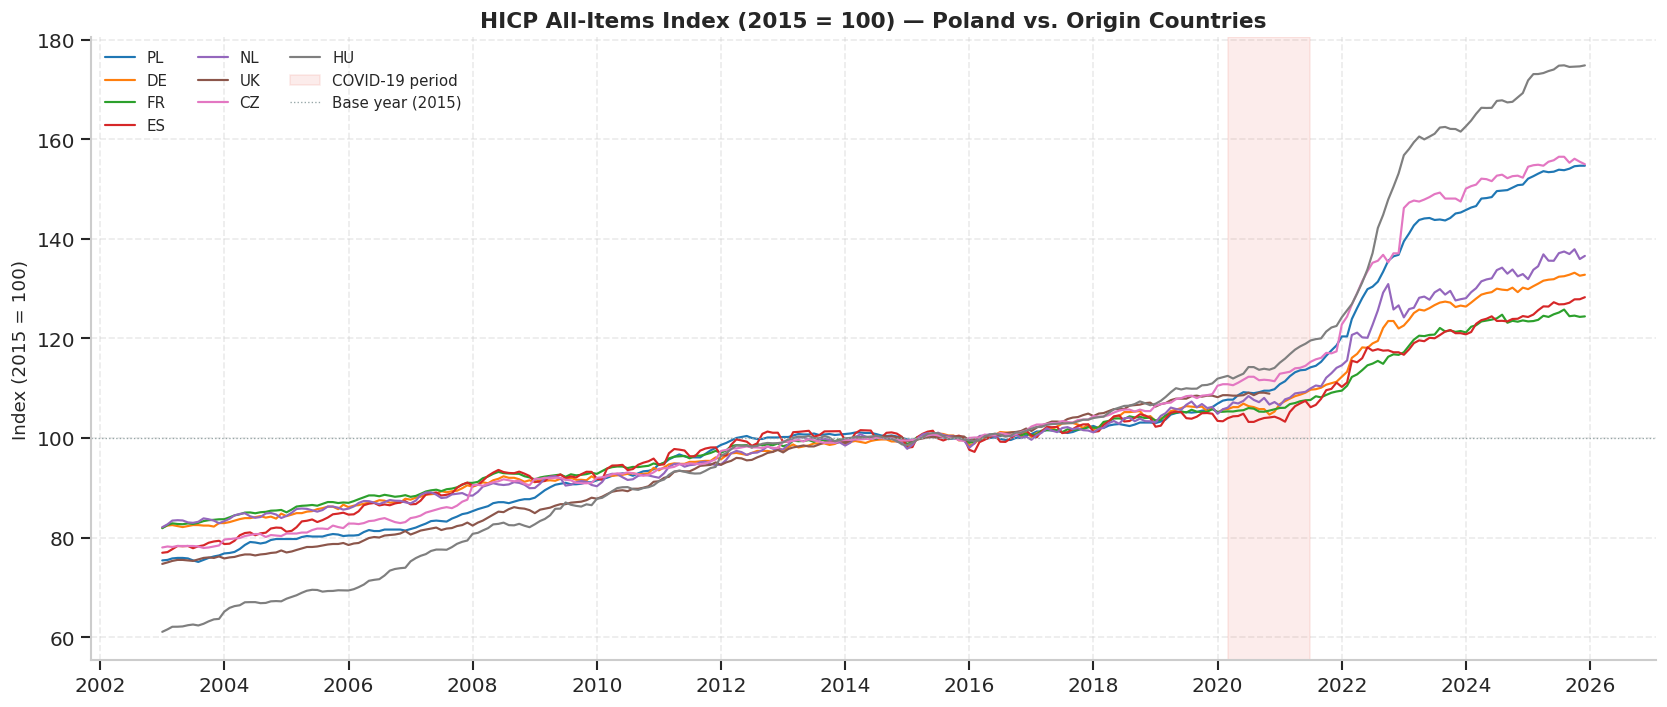

In [196]:
# --- HICP: Poland vs. main origin countries ---
hicp_countries = ['PL', 'DE', 'FR', 'ES', 'NL', 'UK', 'CZ', 'HU']

fig, ax = plt.subplots(figsize=(14, 6))
for iso in hicp_countries:
    s = (df_hicp[df_hicp['iso'] == iso]
         .set_index('date')['OBS_VALUE']
         .sort_index())
    if len(s) > 0:
        ax.plot(s.index, s.values, label=iso, linewidth=1.3)

covid_shade(ax)
ax.axhline(100, ls=':', color=COLORS['gray'], linewidth=0.8,
           label='Base year (2015)')
ax.set_title('HICP All-Items Index (2015 = 100) — Poland vs. Origin Countries')
ax.set_ylabel('Index (2015 = 100)')
ax.legend(ncol=3, loc='upper left')
format_year_axis(ax)
plt.tight_layout()
savefig('07_hicp_comparison.png')
plt.show()

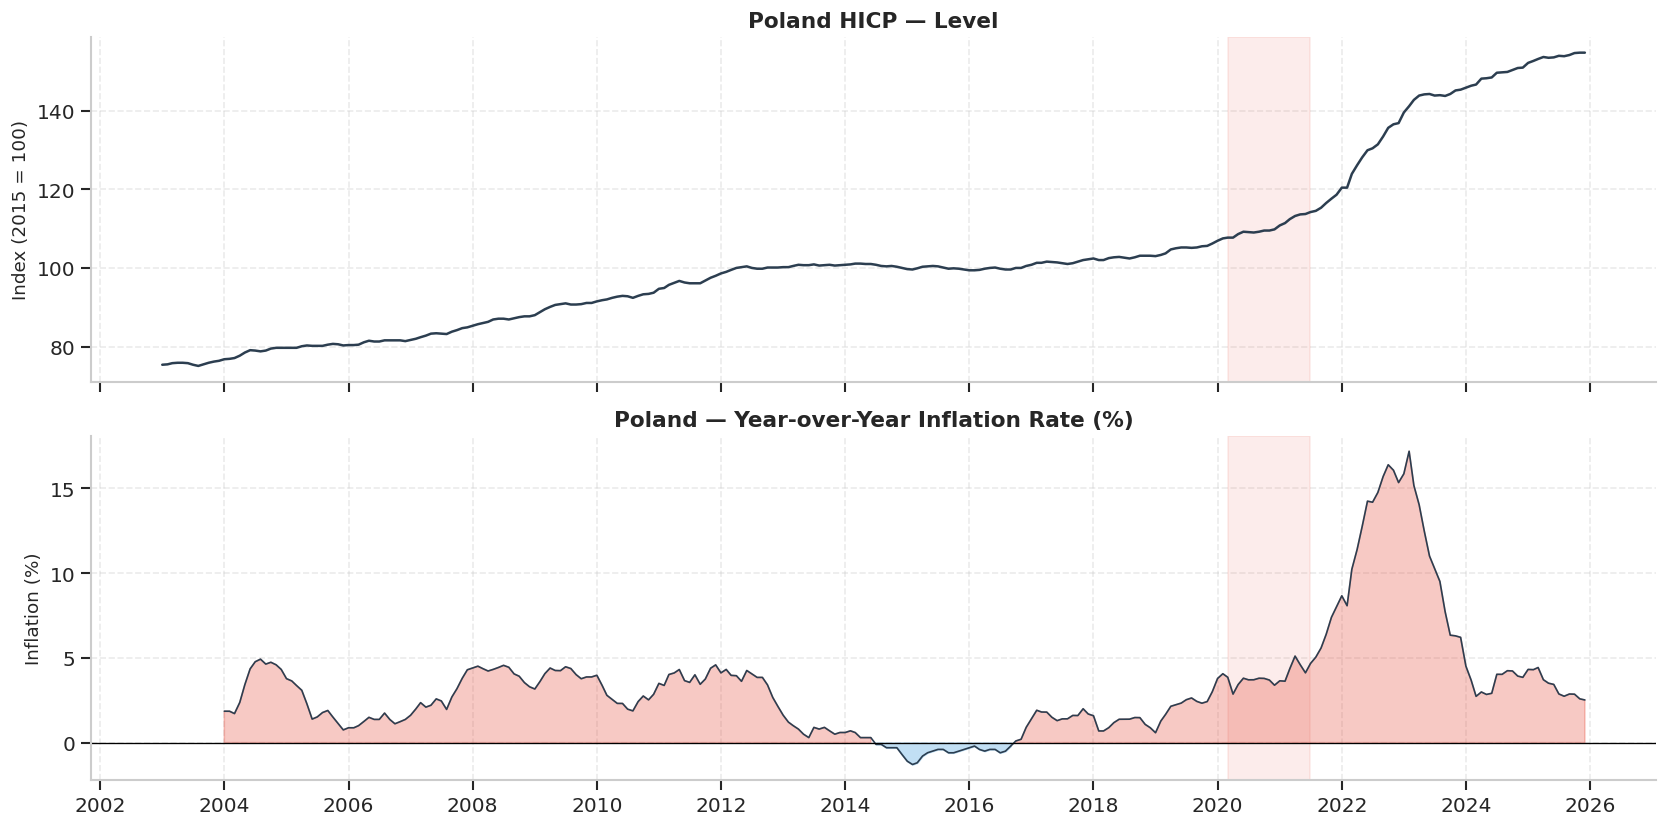

Peak inflation: 17.2% (2023-02)
Latest inflation: 2.5% (2025-12)


In [197]:
# --- Poland inflation rate (YoY from HICP) ---
hicp_pl = (df_hicp[df_hicp['iso'] == 'PL']
           .set_index('date')['OBS_VALUE']
           .sort_index())

inflation_yoy = hicp_pl.pct_change(12) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Level
axes[0].plot(hicp_pl.index, hicp_pl.values,
             color=COLORS['primary'], linewidth=1.5)
covid_shade(axes[0])
axes[0].set_title('Poland HICP — Level')
axes[0].set_ylabel('Index (2015 = 100)')

# YoY inflation
axes[1].fill_between(inflation_yoy.index, 0, inflation_yoy.values,
                     where=inflation_yoy.values >= 0,
                     color=COLORS['secondary'], alpha=0.3)
axes[1].fill_between(inflation_yoy.index, 0, inflation_yoy.values,
                     where=inflation_yoy.values < 0,
                     color=COLORS['accent1'], alpha=0.3)
axes[1].plot(inflation_yoy.index, inflation_yoy.values,
             color=COLORS['primary'], linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8)
covid_shade(axes[1])
axes[1].set_title('Poland — Year-over-Year Inflation Rate (%)')
axes[1].set_ylabel('Inflation (%)')

format_year_axis(axes[1])
plt.tight_layout()
savefig('08_poland_inflation.png')
plt.show()

print(f'Peak inflation: {inflation_yoy.max():.1f}% '
      f'({inflation_yoy.idxmax():%Y-%m})')
print(f'Latest inflation: {inflation_yoy.iloc[-1]:.1f}% '
      f'({inflation_yoy.index[-1]:%Y-%m})')

### 2.2 Exchange Rates

For non-Eurozone origin countries (UK, Sweden, Czechia, Hungary), the exchange rate is a direct component of the relative tourism price. A weaker PLN (more PLN per EUR) makes Poland cheaper for all foreign visitors. Conversely, a stronger origin currency (fewer GBP or SEK per EUR) makes travel to the Eurozone cheaper for those tourists.

For Eurozone-based origin markets (DE, FR, NL, IT, ES, AT), the exchange rate ratio in Song et al.'s formula cancels to 1, so exchange rates only matter for non-Euro currencies.

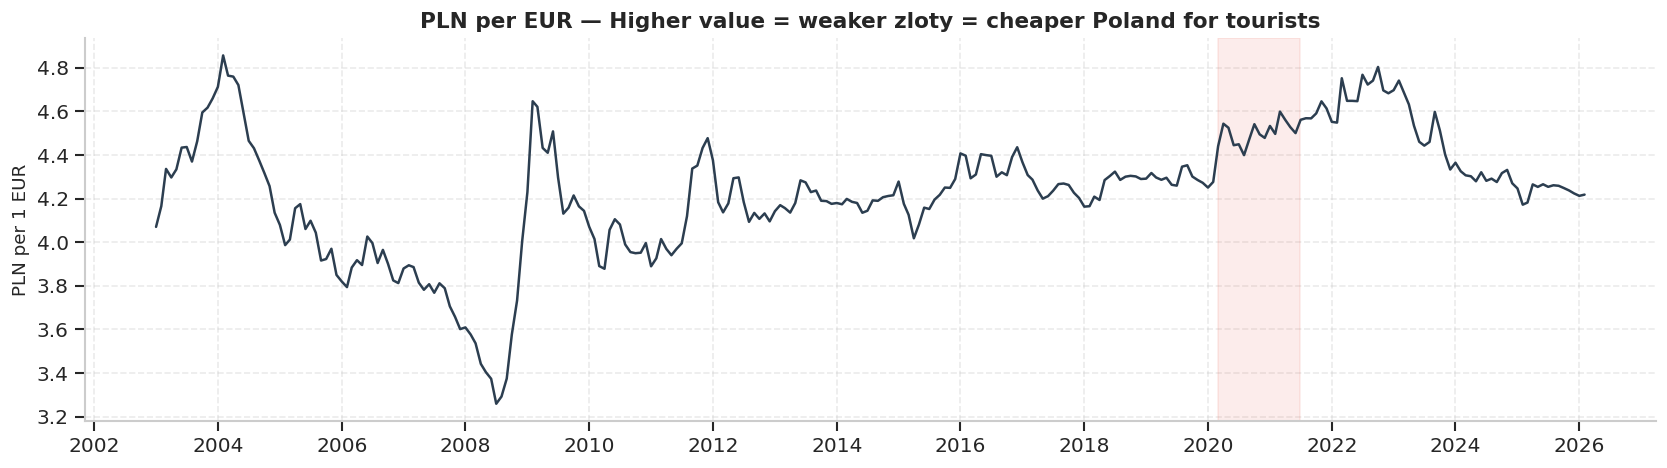

PLN/EUR range: 3.26 — 4.86
Latest: 4.22 (2026-02)


In [198]:
# --- LOAD EXCHANGE RATES ---
df_exr = load_eurostat(FILES['exr'])

# --- PLN/EUR: Poland's own exchange rate ---
pln = (df_exr[df_exr['currency'] == 'Polish zloty']
       .set_index('date')['OBS_VALUE'].sort_index())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pln.index, pln.values, color=COLORS['primary'], linewidth=1.5)
covid_shade(ax)
ax.set_title('PLN per EUR — Higher value = weaker zloty = '
             'cheaper Poland for tourists')
ax.set_ylabel('PLN per 1 EUR')
format_year_axis(ax)
plt.tight_layout()
savefig('09_pln_eur.png')
plt.show()

print(f'PLN/EUR range: {pln.min():.2f} — {pln.max():.2f}')
print(f'Latest: {pln.iloc[-1]:.2f} ({pln.index[-1]:%Y-%m})')

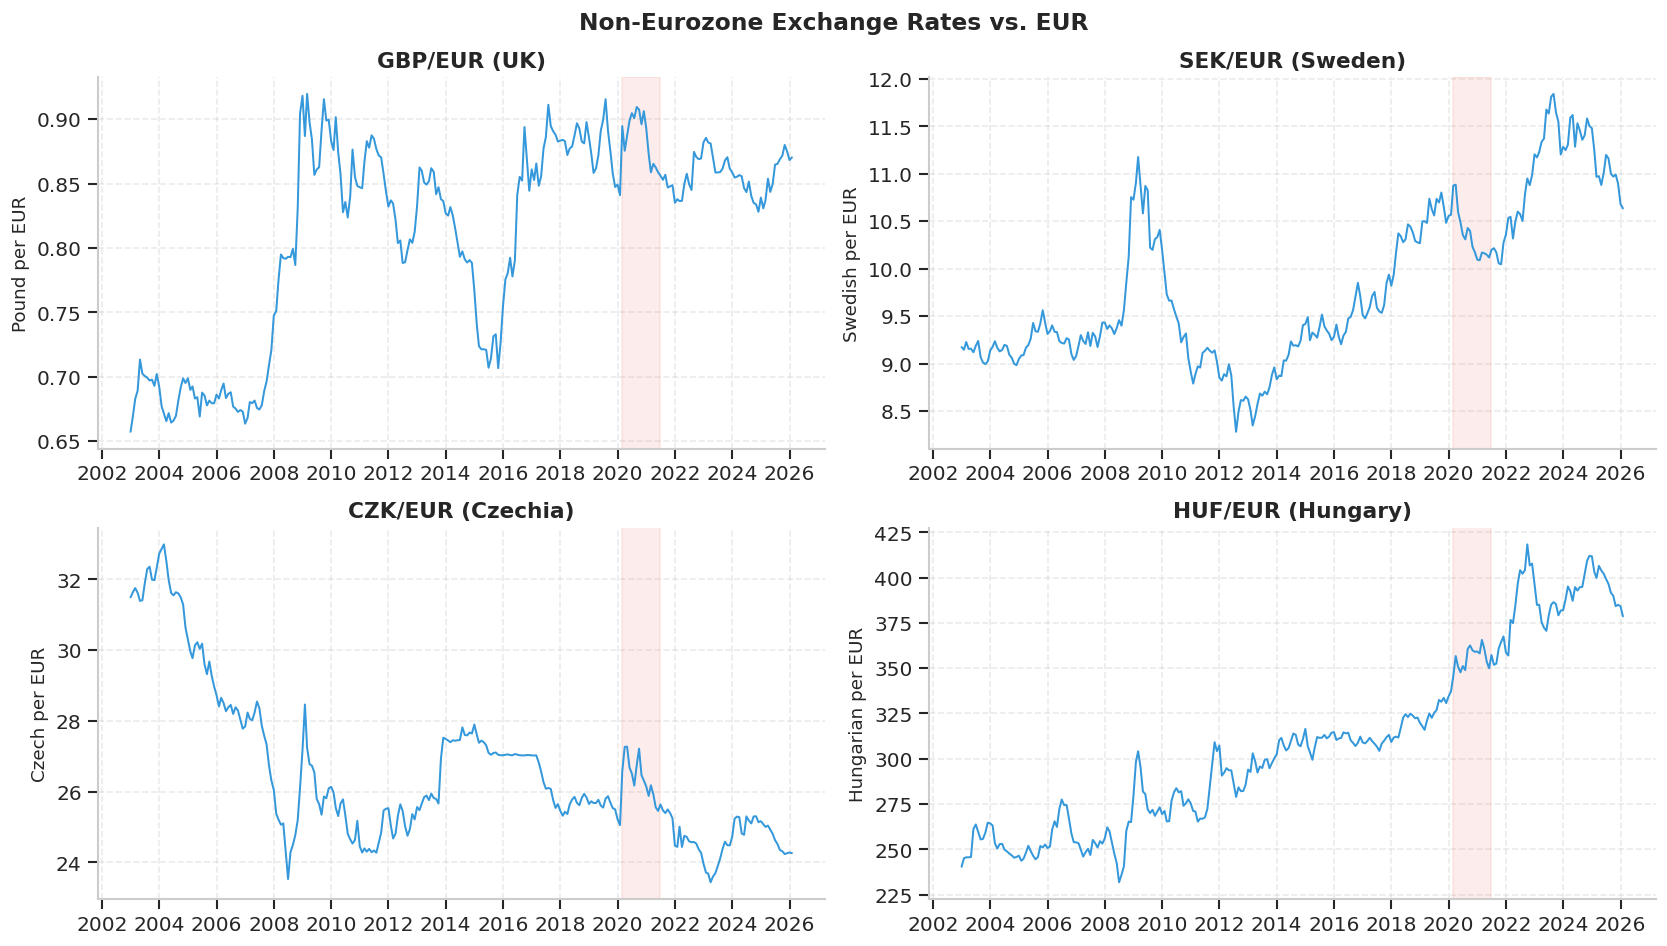

In [199]:
# --- NON-EUROZONE EXCHANGE RATES (2×2 grid) ---
non_euro_curr = {
    'Pound sterling':   'GBP/EUR (UK)',
    'Swedish krona':    'SEK/EUR (Sweden)',
    'Czech koruna':     'CZK/EUR (Czechia)',
    'Hungarian forint': 'HUF/EUR (Hungary)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (curr_name, label) in enumerate(non_euro_curr.items()):
    ax = axes[i // 2][i % 2]
    s = (df_exr[df_exr['currency'] == curr_name]
         .set_index('date')['OBS_VALUE'].sort_index())
    ax.plot(s.index, s.values, color=COLORS['accent1'], linewidth=1.2)
    covid_shade(ax)
    ax.set_title(label)
    ax.set_ylabel(f'{curr_name.split()[0]} per EUR')
    format_year_axis(ax)

plt.suptitle('Non-Eurozone Exchange Rates vs. EUR',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('10_exchange_rates_non_euro.png')
plt.show()

### 2.3 Real GDP of Origin Markets

GDP of origin countries is the primary **income proxy**: as economies grow, discretionary spending on international tourism increases. The series is quarterly, seasonally and calendar adjusted, expressed in chain-linked volumes (2010 base). In Notebook 04, it will be interpolated to monthly frequency using cubic splines.

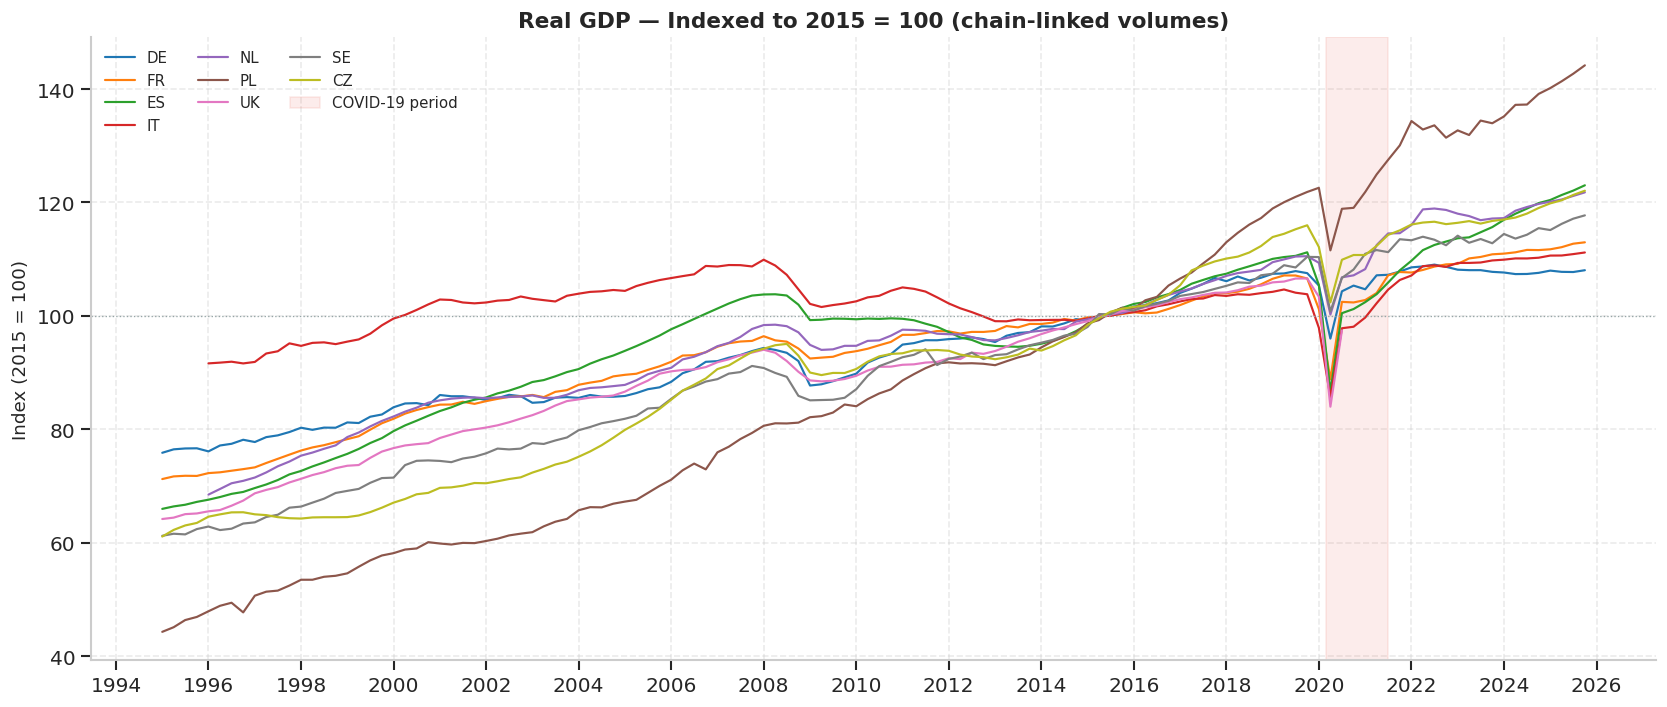

In [200]:
# --- LOAD REAL GDP ---
df_gdp = load_eurostat(FILES['gdp_real'])
df_gdp = add_geo_code(df_gdp)

# Normalise to 2015 = 100 for cross-country comparison
gdp_countries = ['DE', 'FR', 'ES', 'IT', 'NL', 'PL', 'UK', 'SE', 'CZ']

fig, ax = plt.subplots(figsize=(14, 6))
for iso in gdp_countries:
    s = (df_gdp[df_gdp['iso'] == iso]
         .set_index('date')['OBS_VALUE'].sort_index())
    if len(s) == 0:
        continue
    # Rebase to 2015 = 100
    base = s[(s.index >= '2015-01-01') & (s.index < '2016-01-01')].mean()
    if base > 0:
        ax.plot(s.index, (s / base) * 100, label=iso, linewidth=1.3)

covid_shade(ax)
ax.axhline(100, ls=':', color=COLORS['gray'], linewidth=0.8)
ax.set_title('Real GDP — Indexed to 2015 = 100 (chain-linked volumes)')
ax.set_ylabel('Index (2015 = 100)')
ax.legend(ncol=3, loc='upper left')
format_year_axis(ax)
plt.tight_layout()
savefig('11_gdp_origin_countries.png')
plt.show()

### 2.4 Price Level Comparison — Purchasing Power Parities

The PPP-based price level index provides an intuitive snapshot of how expensive Poland is relative to other European countries. An index below 100 means prices are lower than the EU average — a competitive advantage for attracting tourists.

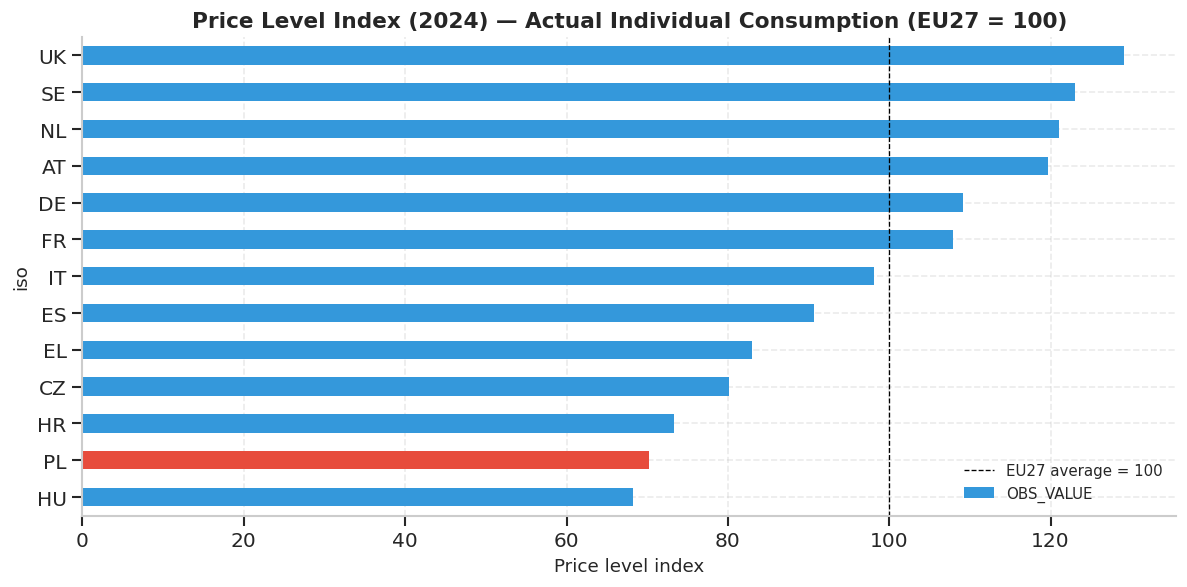

Poland price level: 70.2 (i.e. 30% below EU average)


In [201]:
# --- LOAD PPP ---
df_ppp = load_eurostat(FILES['ppp'], parse_dates=True)
df_ppp = add_geo_code(df_ppp)

# Latest year available
latest_yr = df_ppp['TIME_PERIOD'].max()
ppp_latest = (df_ppp[df_ppp['TIME_PERIOD'] == latest_yr]
              .dropna(subset=['iso']))

# Filter to relevant countries
ppp_countries = ['PL', 'DE', 'FR', 'ES', 'IT', 'NL', 'UK', 'SE',
                 'AT', 'CZ', 'HU', 'HR', 'EL']
ppp_plot = (ppp_latest[ppp_latest['iso'].isin(ppp_countries)]
            .set_index('iso')['OBS_VALUE']
            .sort_values())

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [COLORS['secondary'] if c == 'PL' else COLORS['accent1']
              for c in ppp_plot.index]
ppp_plot.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(100, ls='--', color='black', linewidth=0.8,
           label='EU27 average = 100')
ax.set_title(f'Price Level Index ({latest_yr}) — Actual Individual Consumption '
             f'(EU27 = 100)', fontweight='bold')
ax.set_xlabel('Price level index')
ax.legend()
plt.tight_layout()
savefig('12_ppp_price_levels.png')
plt.show()

pl_val = ppp_plot.get('PL', None)
if pl_val:
    print(f'Poland price level: {pl_val:.1f} '
          f'(i.e. {100 - pl_val:.0f}% below EU average)')

---

## 3. Transport / Aviation Block

Air connectivity is a critical enabler of international tourism. This section examines airline seat capacity at Polish airports (the supply-side variable), air passenger flows by partner country (descriptive validation of origin-market composition), and airport-level trends.

**Endogeneity reminder:** Airlines adjust capacity based on expected demand, creating a simultaneity concern. In the modelling stage, seat capacity will be used with a 6–12 month lag (reflecting IATA slot allocation lead times) or treated as a structural/descriptive variable.

### 3.1 Airline Seats Available — National Aggregate

The `avia_tf_aca` dataset provides monthly data on seats available, passengers on board, and commercial flights at each Polish airport. We aggregate **seats across all airports** to obtain a national-level connectivity measure.

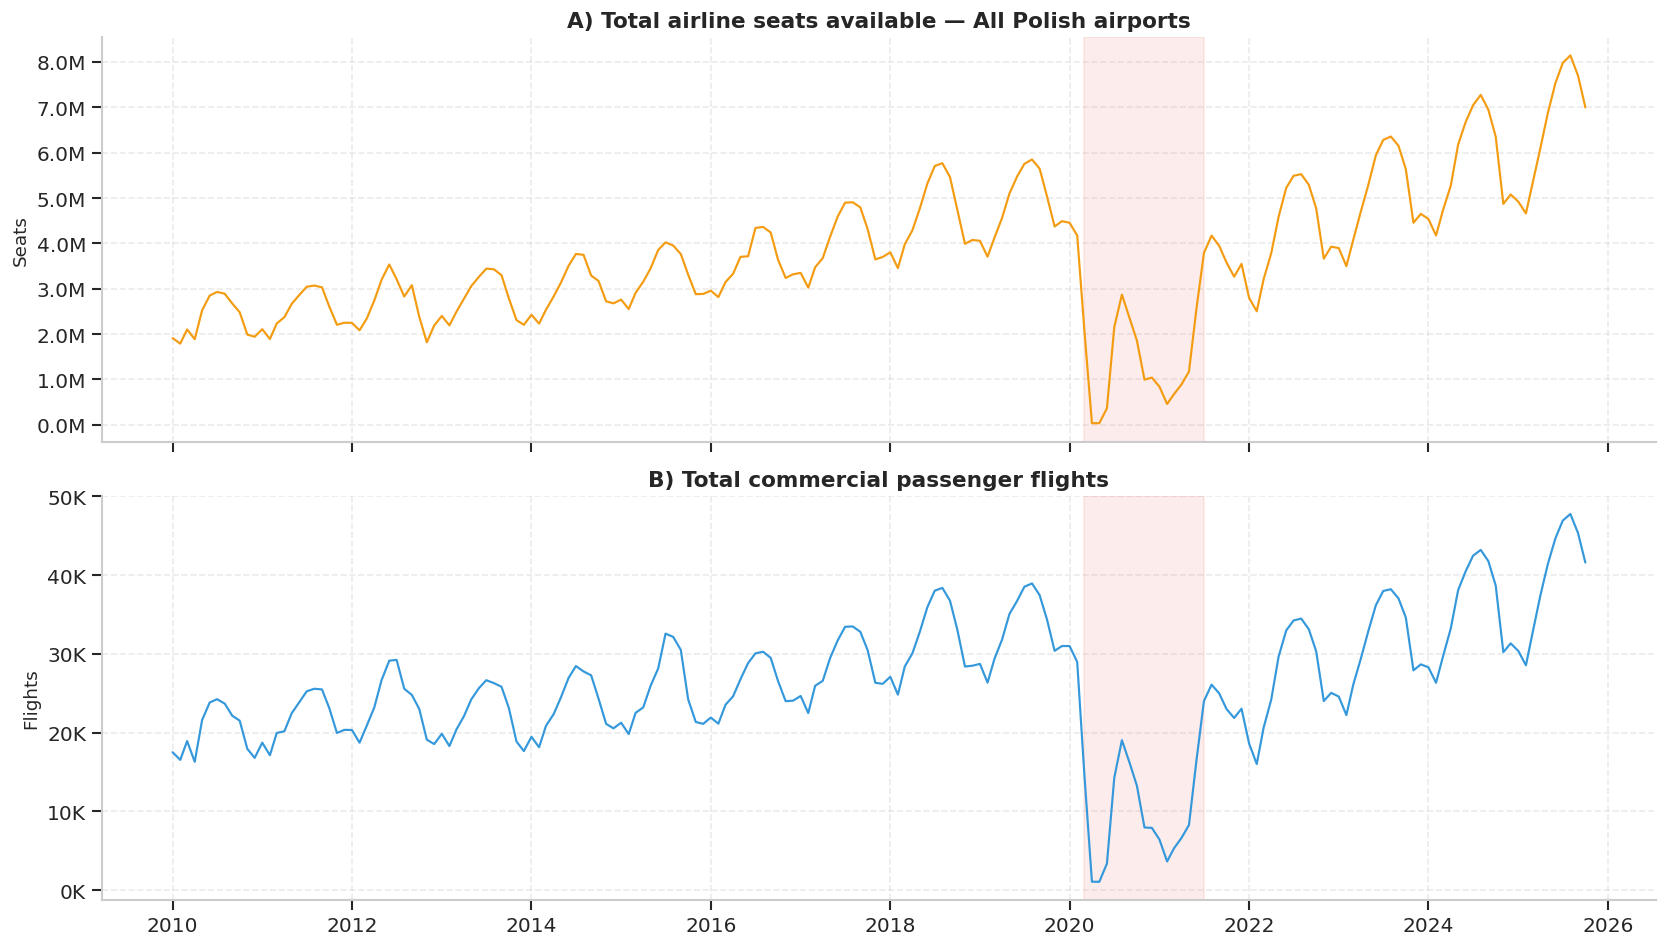

Pre-COVID peak seats: 5,850,139 (2019-08)
Latest seats:         6,999,227 (2025-10)


In [202]:
# --- LOAD AVIATION DATA ---
df_avia = load_eurostat(FILES['avia_seats'])

# Filter to seats available, aggregate across all airports
seats_total = (
    df_avia[df_avia['tra_meas'] == 'Passengers seats available']
    .groupby('date')['OBS_VALUE']
    .sum()
    .sort_index()
)

flights_total = (
    df_avia[df_avia['tra_meas'] == 'Commercial passenger air flights']
    .groupby('date')['OBS_VALUE']
    .sum()
    .sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Seats
axes[0].plot(seats_total.index, seats_total.values,
             color=COLORS['accent3'], linewidth=1.3)
covid_shade(axes[0])
axes[0].set_title('A) Total airline seats available — All Polish airports')
axes[0].set_ylabel('Seats')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))

# Flights
axes[1].plot(flights_total.index, flights_total.values,
             color=COLORS['accent1'], linewidth=1.3)
covid_shade(axes[1])
axes[1].set_title('B) Total commercial passenger flights')
axes[1].set_ylabel('Flights')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e3:.0f}K'))

for ax in axes:
    format_year_axis(ax)

plt.tight_layout()
savefig('13_aviation_seats_flights.png')
plt.show()

pre = seats_total[seats_total.index < '2020-01-01']
print(f'Pre-COVID peak seats: {pre.max():,.0f} ({pre.idxmax():%Y-%m})')
print(f'Latest seats:         {seats_total.iloc[-1]:,.0f} '
      f'({seats_total.index[-1]:%Y-%m})')

### 3.2 Air Passengers by Partner Country — Origin Market Composition

Since `tour_occ_nim` does not break down overnight stays by origin country, the air passenger dataset (`avia_paoc`) provides the best available **proxy for the relative importance of each origin market**. This is purely descriptive — air passengers are not used as a model predictor due to endogeneity.

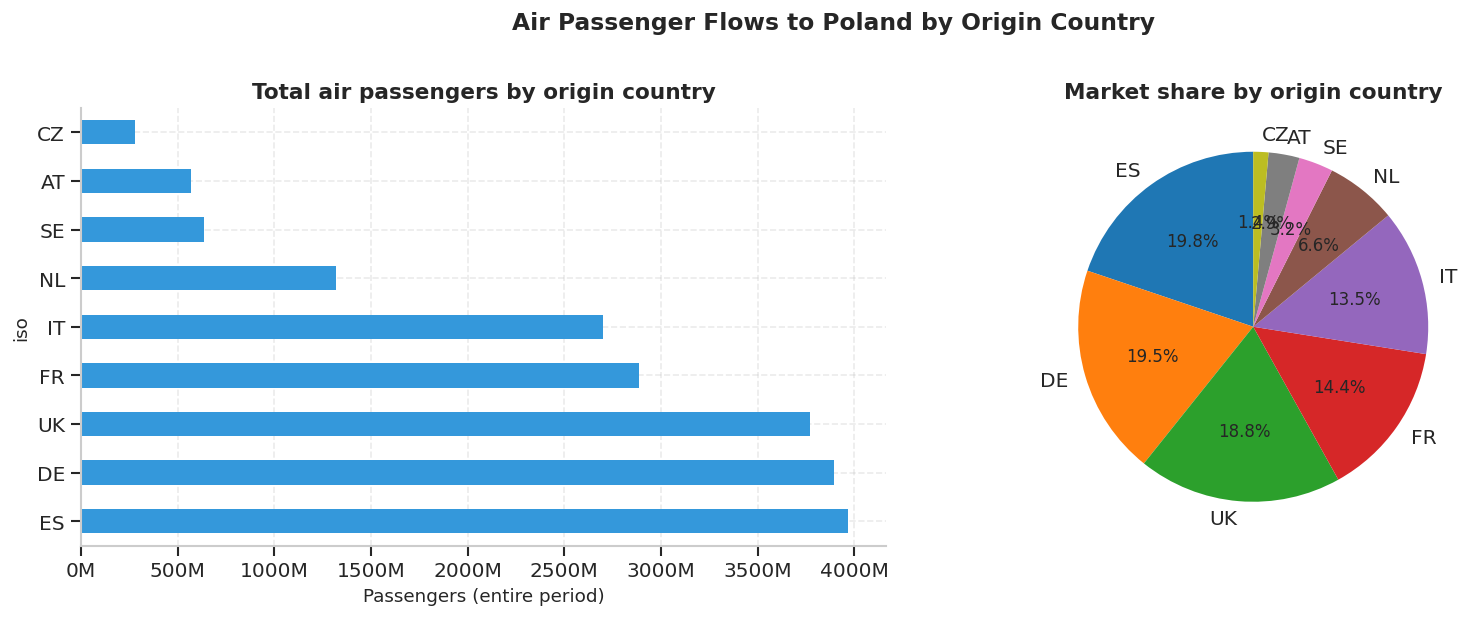

Market shares:
  ES: 19.8%
  DE: 19.5%
  UK: 18.8%
  FR: 14.4%
  IT: 13.5%
  NL: 6.6%
  SE: 3.2%
  AT: 2.9%
  CZ: 1.4%


In [203]:
# --- LOAD AIR PASSENGERS BY COUNTRY ---
df_pax = load_eurostat(FILES['avia_pax'])
df_pax = add_geo_code(df_pax)

# Exclude Poland itself (domestic) and keep only our target origins
origin_codes = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']
df_pax_origins = df_pax[df_pax['iso'].isin(origin_codes)].copy()

# Total passengers per origin (entire period)
pax_total = (df_pax_origins.groupby('iso')['OBS_VALUE']
             .sum()
             .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
pax_total.plot(kind='barh', ax=axes[0], color=COLORS['accent1'])
axes[0].set_title('Total air passengers by origin country')
axes[0].set_xlabel('Passengers (entire period)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M'))

# Market share pie chart
pax_total.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Market share by origin country')
axes[1].set_ylabel('')

plt.suptitle('Air Passenger Flows to Poland by Origin Country',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('14_origin_country_passengers.png')
plt.show()

print('Market shares:')
shares = (pax_total / pax_total.sum() * 100).round(1)
for iso, share in shares.items():
    print(f'  {iso}: {share:.1f}%')

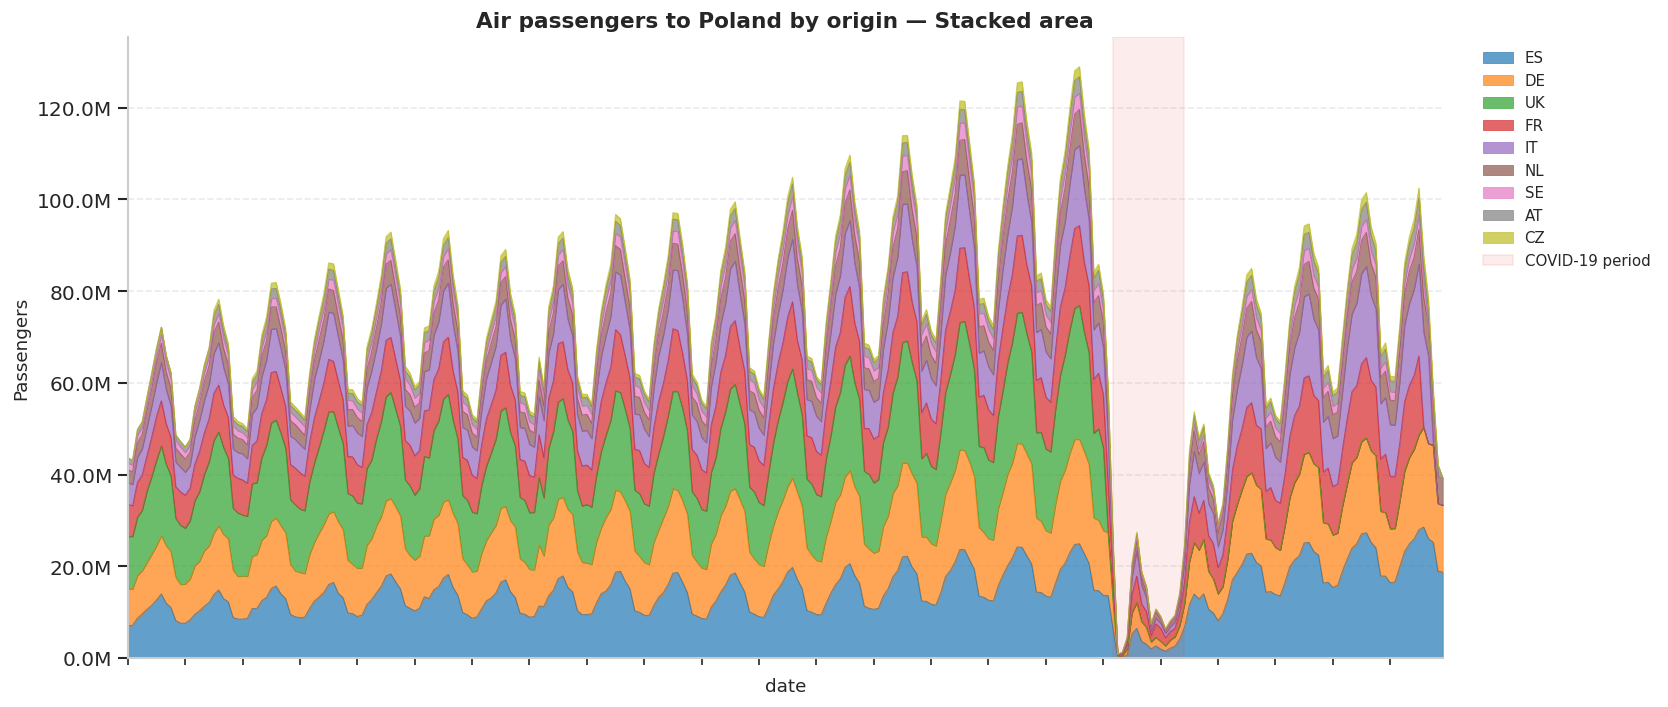

In [204]:
# --- STACKED AREA: Evolution of origin markets over time ---
pivot_pax = (df_pax_origins
             .pivot_table(index='date', columns='iso',
                          values='OBS_VALUE', aggfunc='sum')
             .fillna(0))

# Order by total volume
order = pivot_pax.sum().sort_values(ascending=False).index
pivot_pax = pivot_pax[order]

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pax.plot.area(ax=ax, alpha=0.7, linewidth=0.5)
covid_shade(ax)
ax.set_title('Air passengers to Poland by origin — Stacked area',
             fontweight='bold')
ax.set_ylabel('Passengers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
format_year_axis(ax)
plt.tight_layout()
savefig('15_stacked_area_origins.png')
plt.show()

### 3.3 Airport-Level Passenger Distribution

Poland's aviation market is distributed across multiple airports, with Warsaw Chopin as the dominant hub. The growth of regional airports (especially those served by LCCs like Wizz Air and Ryanair) has been a key structural driver of tourism accessibility.

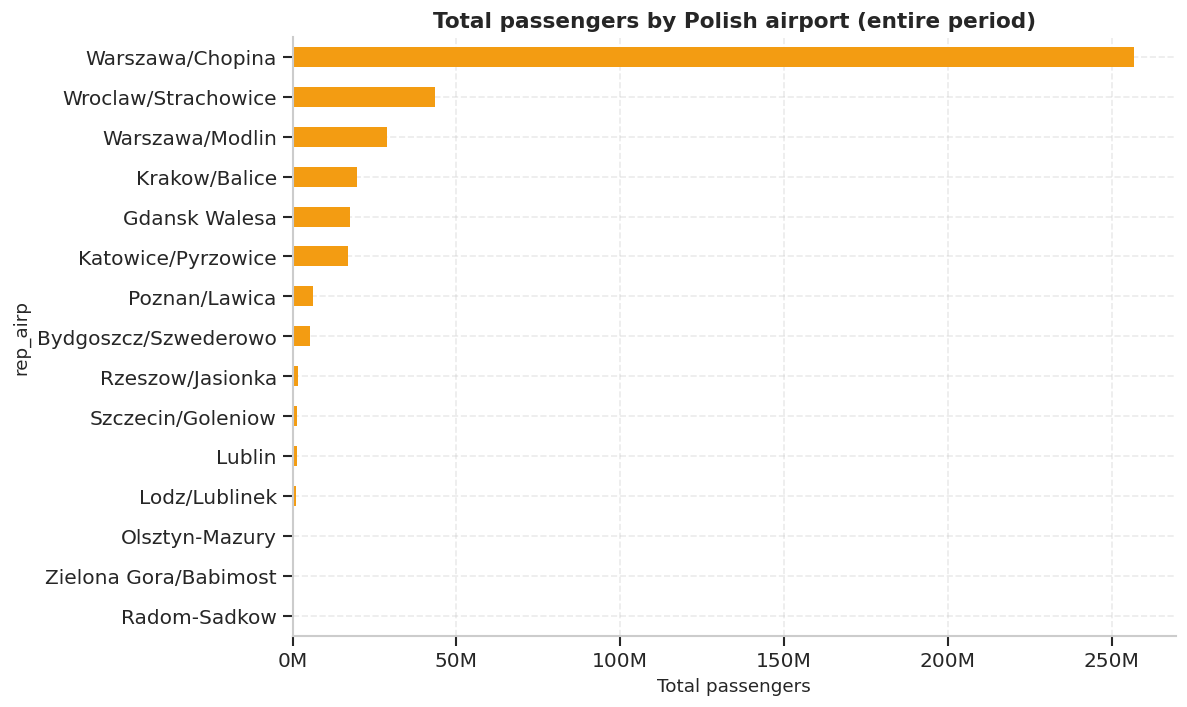

In [205]:
# --- LOAD AIRPORT DATA ---
df_airports = load_eurostat(FILES['avia_airports'])

# Aggregate per airport over the entire period
airport_totals = (df_airports.groupby('rep_airp')['OBS_VALUE']
                  .sum()
                  .sort_values(ascending=True))

# Shorten names for readability
airport_totals.index = (airport_totals.index
    .str.replace(' airport', '', regex=False)
    .str.replace('IM LECHA WALESY', 'Walesa', regex=False)
    .str.title())

fig, ax = plt.subplots(figsize=(10, 6))
airport_totals.plot(kind='barh', ax=ax, color=COLORS['accent3'])
ax.set_title('Total passengers by Polish airport (entire period)',
             fontweight='bold')
ax.set_xlabel('Total passengers')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
savefig('16_airport_passengers.png')
plt.show()

---

## 4. Sentiment & Demographic Variables

Consumer sentiment in origin markets captures the **psychological willingness to spend** on discretionary items like tourism, beyond what income levels alone predict. Population provides a scaling context.

### 4.1 Consumer Confidence Indicator

The Eurostat consumer confidence indicator is a monthly balance statistic (values above 0 indicate optimism, below 0 indicate pessimism). It is seasonally adjusted and available for all origin markets except the UK.

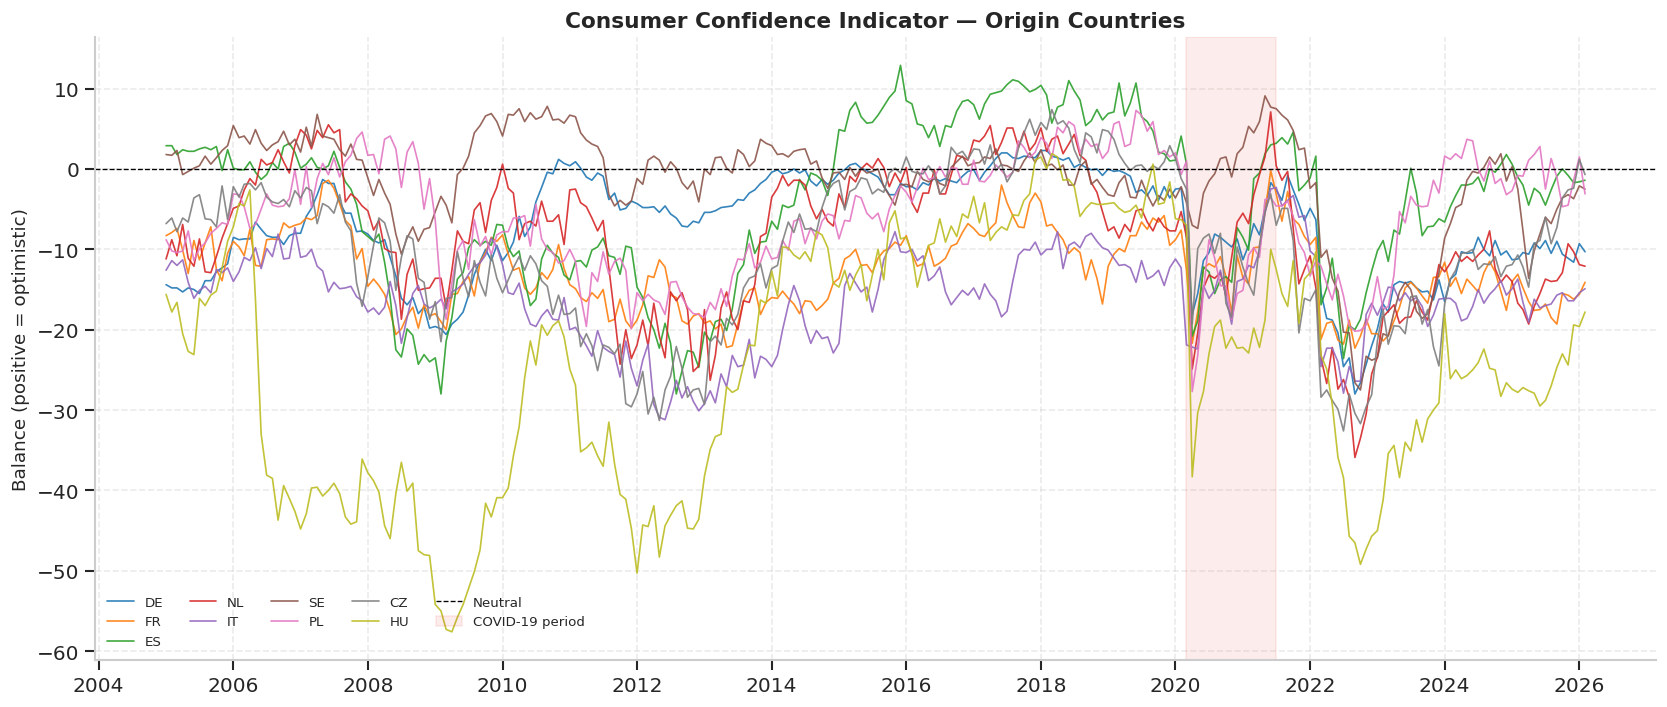

In [206]:
# --- LOAD CONSUMER CONFIDENCE ---
df_cci = load_eurostat(FILES['cci'])
df_cci = add_geo_code(df_cci)

cci_countries = ['DE', 'FR', 'ES', 'NL', 'IT', 'SE', 'PL', 'CZ', 'HU']

fig, ax = plt.subplots(figsize=(14, 6))
for iso in cci_countries:
    s = (df_cci[df_cci['iso'] == iso]
         .set_index('date')['OBS_VALUE']
         .sort_index())
    if len(s) > 0:
        ax.plot(s.index, s.values, label=iso, linewidth=1.0,
                alpha=0.9)

ax.axhline(0, color='black', linewidth=0.8, ls='--',
           label='Neutral')
covid_shade(ax)
ax.set_title('Consumer Confidence Indicator — Origin Countries')
ax.set_ylabel('Balance (positive = optimistic)')
ax.legend(ncol=5, loc='lower left', fontsize=8)
format_year_axis(ax)
plt.tight_layout()
savefig('17_consumer_confidence.png')
plt.show()

### 4.2 Population of Origin Markets

Population is a structural scaling factor: larger countries naturally generate more outbound tourism. The table below shows the latest available population for each origin market.

In [207]:
# --- LOAD POPULATION ---
df_pop = load_eurostat(FILES['population'], parse_dates=True)
df_pop = add_geo_code(df_pop)

pop_countries = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ', 'PL']
latest_year = df_pop['TIME_PERIOD'].max()

pop_latest = (df_pop[(df_pop['TIME_PERIOD'] == latest_year) &
                     (df_pop['iso'].isin(pop_countries))]
              .set_index('iso')['OBS_VALUE']
              .sort_values(ascending=False))

print(f'Population of origin markets ({latest_year}):')
for iso, val in pop_latest.items():
    print(f'  {iso} ({CODE_TO_NAME.get(iso, iso)}): {val:,.0f}')

Population of origin markets (2025):
  DE (Germany): 83,577,140
  FR (France): 68,882,600
  IT (Italy): 58,943,464
  ES (Spain): 49,128,297
  PL (Poland): 36,497,495
  NL (Netherlands): 18,044,027
  CZ (Czechia): 10,909,500
  SE (Sweden): 10,587,710
  AT (Austria): 9,197,213


---

## 5. Preliminary Insights & Synthesis

### 5.1 Key Findings from the Descriptive Analysis

**Target variable (foreign overnight stays):**

- The series spans **179 monthly observations** (2011-01 to 2025-11) with **zero missing values**, ranging from 83,695 to 2,453,961 overnight stays per month (mean: ~1.19 million).
- **Strong but moderate seasonality:** the peak-to-trough ratio is **2.4x** (August average: 1.87M vs. January average: 783K). This is lower than expected for a Mediterranean destination, reflecting Poland's profile as a mixed business-cultural-leisure destination rather than a purely seasonal sun-and-beach market. Notably, the seasonal decline after summer is gradual — September and October remain elevated relative to spring months, likely driven by urban cultural tourism, the academic year (Poland hosts ~90,000 international students), and autumn business travel/congress activity.
- The **pre-COVID peak** occurred in July 2019 (2,260,446 nights). The **COVID trough** in April 2020 (83,695 nights) represents a **96.3% collapse** — among the most severe in European tourism.
- The **recovery was slow and asymmetric:** the rolling 12-month sum shows that annualised demand did not return to pre-pandemic levels until approximately mid-2023, a full two years after restrictions eased. This extended recovery period has important implications for modelling: a simple binary COVID dummy (March 2020 – June 2021) may be insufficient, and a multi-phase specification (acute lockdown + gradual recovery) should be tested in Notebook 05.
- The distribution is remarkably close to **normal** (skewness: 0.011, kurtosis: −0.036, Shapiro-Wilk p = 0.43), which is unusual for monthly tourism data and suggests that the seasonal pattern, while present, does not dominate the variance to the extent seen in purely seasonal destinations.
- **Foreign tourists account for approximately 18.8% of total overnight stays** in Poland (range: 7.1%–25.7%). The foreign share dropped sharply during COVID (reaching 7.1%) and has been recovering but remains below its pre-pandemic highs, suggesting that domestic tourism recovered faster than international demand.

**Economic / price variables:**

- Poland's HICP has risen **faster than all origin countries** since 2021, reaching a peak year-over-year inflation of **17.2% in February 2023** — the highest among all countries in the sample. By December 2025, inflation had moderated to 2.5%. This inflationary episode is expected to have eroded Poland's price competitiveness, though the effect may be partially offset by exchange rate movements.
- The **PLN/EUR exchange rate** has fluctuated between 3.26 and 4.86 over the study period, with the latest value at 4.22 (February 2026). The medium-term weakening of the zloty during 2022–2023 may have partially cushioned the HICP-driven loss of competitiveness — a dynamic that the relative tourism price variable (Song et al., 2010) is designed to capture.
- Poland's **price level (PPP) stands at 70.2**, meaning prices are approximately **30% below the EU average**. This structural price advantage is a significant competitive factor for inbound tourism, particularly from high-cost origin markets like Germany (where prices are above the EU average).
- Real GDP across major origin countries shows a consistent **post-COVID V-shaped recovery**, with most returning to or exceeding pre-pandemic output levels by 2022. The UK series ends in 2020-Q3 (Brexit reporting gap) and requires supplementation.

**Transport / aviation:**

- Airline seat capacity has exceeded pre-COVID levels: the latest observation (October 2025: **6,999,227 seats**) surpasses the pre-pandemic peak (August 2019: 5,850,139) by **19.6%**. This suggests that supply-side air connectivity is no longer a binding constraint on tourism demand.
- Air passenger market shares reveal a **more balanced origin mix** than expected: Spain leads narrowly at 19.8%, followed closely by Germany (19.5%) and the UK (18.8%), then France (14.4%) and Italy (13.5%). The Netherlands, Sweden, Austria, and Czechia together account for the remaining ~14%. This diversification reduces dependency on any single origin market.
- The **airport distribution** confirms Warsaw Chopin as the dominant gateway, but with substantial traffic at regional airports (Wrocław, Kraków, Gdańsk, Katowice). Wrocław's strong showing — ahead of Kraków in total passenger volume — reflects its role as a major LCC hub (Wizz Air base) and the industrial strength of the Lower Silesia region, which generates significant business travel. Kraków's traffic, while high, may be more seasonal (weekend city-break tourism), whereas Wrocław has a more uniform year-round flow.

**Consumer confidence:**

- Consumer confidence across origin countries shows **highly synchronised cyclical patterns**, with deep and simultaneous troughs during COVID (reaching −25 to −40 across all countries). The post-COVID recovery in confidence preceded the recovery in tourism demand by several months — a pattern consistent with the expected leading-indicator role of sentiment variables. This lag structure will be formally tested in Notebook 02 (cross-correlations) and Notebook 03 (Granger causality).
- The UK is **absent** from the Eurostat consumer confidence dataset, requiring an alternative source (GfK UK Consumer Confidence Index) for the modelling stage.

### 5.2 Variables Carried Forward to Modelling

| Variable | Block | Frequency | Exogeneity | Role in Model |
|----------|-------|-----------|------------|---------------|
| Foreign overnight stays | Target | Monthly | — | Dependent variable |
| HICP (origin countries + PL) | Economic | Monthly | Strong | Relative tourism price (Song et al., 2010) |
| Exchange rates (PLN, GBP, SEK, CZK, HUF) | Economic | Monthly | Strong | Relative tourism price (Will it be useful?) |
| Real GDP (origin countries) | Economic | Quarterly → Monthly | Strong | Income effect |
| Consumer confidence (origin) | Sentiment | Monthly | Strong | Willingness to travel |
| Airline seats available (lagged) | Transport | Monthly | Moderate | Air connectivity (6–12 month lag) |
| COVID-19 dummy (multi-phase) | Control | — | Strong | Structural break: acute + recovery |
| Seasonal dummies (month) | Control | — | Strong | Deterministic seasonality |
| Target lags (t−1, t−12) | Autoregressive | Monthly | — | Persistence and seasonal memory |

### 5.3 COVID-19 Modelling Strategy

**The severity of the COVID shock (96.3% collapse) and the slow recovery (~2 years to pre-pandemic levels)** demand careful treatment in the modelling stage. The following multi-branched strategy will be adopted:

1. **Multi-phase dummy specification:** rather than a single binary dummy, we will try testing a two-phase approach — an acute restriction dummy (2020-03 to 2020-12) and a recovery dummy (2021-01 to 2022-06) — allowing the model to distinguish between the collapse and the gradual return.
2. **Autoregressive components:** target lags (t−1, t−12) will naturally capture the persistence of the post-COVID depression through their own depressed values.
3. **Bayesian Structural Time Series (BSTS):** a BSTS model could be estimated as a complementary baseline (Notebook 05), enabling **counterfactual COVID impact analysis** — estimating how many overnight stays were "lost" by comparing the Bayesian posterior prediction (what would have happened without COVID) against observed data. This leverages the `CausalImpact` framework (Brodersen et al., 2015).
4. **Bayesian Model Averaging (BMA)** will be used during variable/lag selection (Notebook 03) to produce posterior inclusion probabilities for each candidate predictor, providing a probabilistically grounded **alternative to frequentist Granger causality tests**.
5. **Robustness check:** all models will be evaluated both on the full sample and on a restricted sample excluding 2020–2021, to assess whether COVID distorts the estimated relationships.

### 5.4 Questions for Notebook 02 (Multivariate EDA)

The descriptive analysis raises several questions that require formal cross-variable analysis:

1. What is the **optimal lag** between changes in GDP / consumer confidence and changes in overnight stays?
2. Does the **relative tourism price** (HICP ratio × exchange rate) show a statistically meaningful negative correlation with demand?
3. How strongly does airline seat capacity **lead** tourism demand, and at what lag?
4. Are there **asymmetries** in the COVID recovery across economic indicators and tourism demand?
5. Does consumer confidence act as a **leading indicator** of tourism demand — and if so, by how many months?

---

*End of Notebook 01 — Next: [02_multivariate_eda_correlations.ipynb](./02_multivariate_eda_correlations.ipynb)*